# ACS B08201 Census Tract Data Preprocessing

## 1. Environment Setup

### 1.1 Import Required Libraries

In [248]:
# pathlib/re for path handling and GEOID parsing; geopandas for the spatial join step later
from pathlib import Path
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display


### 1.2 Configure Display Settings

In [249]:
# Widen pandas display so wide ACS tables don't truncate mid-inspection
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)


### 1.3 Define Input and Output File Paths

In [250]:
# Fall back to cwd if the Windows project path isn't found (e.g. running on a different machine)
WINDOWS_PROJECT_ROOT = Path(r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp")
PROJECT_ROOT = WINDOWS_PROJECT_ROOT if WINDOWS_PROJECT_ROOT.exists() else Path.cwd()

# Define the subfolders holding the ACS data, FIPS reference, and tract boundary files
VEHICLE_DIR = PROJECT_ROOT / "data" / "census_acs" / "vehicle_availability"
REFERENCE_DIR = PROJECT_ROOT / "data" / "census_acs" / "Reference"
TRACT_BOUNDARY_DIR = PROJECT_ROOT / "data" / "census_acs" / "tract_boundaries"


# Handles "(1)" duplicate-download filenames from repeated Census exports
def resolve_existing_path(*candidates):
    for candidate in candidates:
        if Path(candidate).exists():
            return Path(candidate)
    raise FileNotFoundError(f"None of the candidate paths exist: {candidates}")


# Locate each required input file, checking both the normal and "(1)" filename variants
ACS_PATH = resolve_existing_path(
    VEHICLE_DIR / "ACSDT5Y2024.B08201-Data.csv",
    VEHICLE_DIR / "ACSDT5Y2024.B08201-Data(1).csv",
)
METADATA_PATH = resolve_existing_path(
    VEHICLE_DIR / "ACSDT5Y2024.B08201-Column-Metadata.csv",
    VEHICLE_DIR / "ACSDT5Y2024.B08201-Column-Metadata(1).csv",
)
NOTES_PATH = resolve_existing_path(
    VEHICLE_DIR / "ACSDT5Y2024.B08201-Table-Notes.txt",
    VEHICLE_DIR / "ACSDT5Y2024.B08201-Table-Notes(1).txt",
)
SHAPEFILE_PATH = resolve_existing_path(
    TRACT_BOUNDARY_DIR / "tl_2024_36_tract.shp",
    TRACT_BOUNDARY_DIR / "tl_2024_36_tract(1).shp",
    VEHICLE_DIR / "tl_2024_36_tract.shp",
    VEHICLE_DIR / "tl_2024_36_tract(1).shp",
)
FIPS_PATH = REFERENCE_DIR / "census_tract_fips_code.xlsx"

# Define where the processed outputs will be written
OUTPUT_DIR = PROJECT_ROOT / "processed_outputs" / "census_tract"
CSV_OUTPUT_PATH = OUTPUT_DIR / "nyc_zero_vehicle_households_by_tract.csv"
GPKG_OUTPUT_PATH = OUTPUT_DIR / "nyc_zero_vehicle_households_by_tract.gpkg"

# Fail fast if any required input file is missing
paths = {
    "ACS data": ACS_PATH,
    "Column metadata": METADATA_PATH,
    "Table notes": NOTES_PATH,
    "County FIPS reference": FIPS_PATH,
    "Tract shapefile": SHAPEFILE_PATH,
}
path_check = pd.DataFrame({
    "path": [str(path) for path in paths.values()],
    "exists": [path.exists() for path in paths.values()]
}, index=paths.keys())
display(path_check)
assert path_check["exists"].all(), "One or more required input files could not be found."


,path,exists
ACS data,C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\data\census_acs\ve...,True
Column metadata,C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\data\census_acs\ve...,True
Table notes,C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\data\census_acs\ve...,True
County FIPS reference,C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\data\census_acs\Re...,True
Tract shapefile,C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\data\census_acs\tr...,True


**Interpretation:** All five required input files were found, so preprocessing can continue.

## 2. Load, Inspect, and Prepare the ACS Dataset Structure

### 2.1 Load the Raw ACS Data

In [251]:
# Read as strings to avoid pandas guessing dtypes on Census placeholder codes
acs_raw = pd.read_csv(ACS_PATH, dtype=str)
acs_raw.shape


(7415, 63)

**Interpretation:** The ACS file loaded with 7,415 rows and 63 columns, including one descriptive row.

### 2.2 Inspect the Loaded Object Type

In [252]:
# Confirm the CSV loaded as a standard DataFrame
type(acs_raw)


pandas.core.frame.DataFrame

**Interpretation:** The object is a pandas DataFrame, so tabular inspection can continue.

In [253]:
# Row/column counts before any cleaning, for later before/after comparison
raw_shape = acs_raw.shape
pd.DataFrame({"rows": [raw_shape[0]], "columns": [raw_shape[1]]})


,rows,columns
0,7415,63


**Interpretation:** The original dimensions are recorded as 7,415 rows and 63 columns for later comparison.

### 2.3 Inspect the First Records

In [254]:
# Eyeball the first few records
display(acs_raw.head())


,GEO_ID,NAME,B08201_001E,B08201_001M,B08201_002E,B08201_002M,B08201_003E,B08201_003M,B08201_004E,B08201_004M,B08201_005E,B08201_005M,B08201_006E,B08201_006M,B08201_007E,B08201_007M,B08201_008E,B08201_008M,B08201_009E,B08201_009M,B08201_010E,B08201_010M,B08201_011E,B08201_011M,B08201_012E,B08201_012M,B08201_013E,B08201_013M,B08201_014E,B08201_014M,B08201_015E,B08201_015M,B08201_016E,B08201_016M,B08201_017E,B08201_017M,B08201_018E,B08201_018M,B08201_019E,B08201_019M,B08201_020E,B08201_020M,B08201_021E,B08201_021M,B08201_022E,B08201_022M,B08201_023E,B08201_023M,B08201_024E,B08201_024M,B08201_025E,B08201_025M,B08201_026E,B08201_026M,B08201_027E,B08201_027M,B08201_028E,B08201_028M,B08201_029E,B08201_029M,B08201_030E,B08201_030M,Unnamed: 62
0,Geography,Geographic Area Name,Estimate!!Total:,Margin of Error!!Total:,Estimate!!Total:!!No vehicle available,Margin of Error!!Total:!!No vehicle available,Estimate!!Total:!!1 vehicle available,Margin of Error!!Total:!!1 vehicle available,Estimate!!Total:!!2 vehicles available,Margin of Error!!Total:!!2 vehicles available,Estimate!!Total:!!3 vehicles available,Margin of Error!!Total:!!3 vehicles available,Estimate!!Total:!!4 or more vehicles available,Margin of Error!!Total:!!4 or more vehicles available,Estimate!!Total:!!1-person household:,Margin of Error!!Total:!!1-person household:,Estimate!!Total:!!1-person household:!!No vehicle available,Margin of Error!!Total:!!1-person household:!!No vehicle available,Estimate!!Total:!!1-person household:!!1 vehicle available,Margin of Error!!Total:!!1-person household:!!1 vehicle available,Estimate!!Total:!!1-person household:!!2 vehicles available,Margin of Error!!Total:!!1-person household:!!2 vehicles available,Estimate!!Total:!!1-person household:!!3 vehicles available,Margin of Error!!Total:!!1-person household:!!3 vehicles available,Estimate!!Total:!!1-person household:!!4 or more vehicles available,Margin of Error!!Total:!!1-person household:!!4 or more vehicles available,Estimate!!Total:!!2-person household:,Margin of Error!!Total:!!2-person household:,Estimate!!Total:!!2-person household:!!No vehicle available,Margin of Error!!Total:!!2-person household:!!No vehicle available,Estimate!!Total:!!2-person household:!!1 vehicle available,Margin of Error!!Total:!!2-person household:!!1 vehicle available,Estimate!!Total:!!2-person household:!!2 vehicles available,Margin of Error!!Total:!!2-person household:!!2 vehicles available,Estimate!!Total:!!2-person household:!!3 vehicles available,Margin of Error!!Total:!!2-person household:!!3 vehicles available,Estimate!!Total:!!2-person household:!!4 or more vehicles available,Margin of Error!!Total:!!2-person household:!!4 or more vehicles available,Estimate!!Total:!!3-person household:,Margin of Error!!Total:!!3-person household:,Estimate!!Total:!!3-person household:!!No vehicle available,Margin of Error!!Total:!!3-person household:!!No vehicle available,Estimate!!Total:!!3-person household:!!1 vehicle available,Margin of Error!!Total:!!3-person household:!!1 vehicle available,Estimate!!Total:!!3-person household:!!2 vehicles available,Margin of Error!!Total:!!3-person household:!!2 vehicles available,Estimate!!Total:!!3-person household:!!3 vehicles available,Margin of Error!!Total:!!3-person household:!!3 vehicles available,Estimate!!Total:!!3-person household:!!4 or more vehicles available,Margin of Error!!Total:!!3-person household:!!4 or more vehicles available,Estimate!!Total:!!4-or-more-person household:,Margin of Error!!Total:!!4-or-more-person household:,Estimate!!Total:!!4-or-more-person household:!!No vehicle available,Margin of Error!!Total:!!4-or-more-person household:!!No vehicle available,Estimate!!Total:!!4-or-more-person household:!!1 vehicle available,Margin of Error!!Total:!!4-or-more-person household:!!1 vehicle available,Estimate!!Total:!!4-or-more-person household:!!2 vehicles available,Margin of Error!!Total:!!4-or-more-person household:!!2 vehicles available,Estimate!!Total:!!4-

**Interpretation:** The first record contains descriptive labels while the following records contain tract identifiers and values.

### 2.4 Inspect the GEO_ID Pattern to Identify Non-Data Rows

In [255]:
# Census tract GEO_IDs follow "1400000US" + 11-digit FIPS; anything else is a metadata row
tract_pattern = r"1400000US\d{11}"
geo_pattern_check = pd.DataFrame({
    "GEO_ID": acs_raw["GEO_ID"],
    "length": acs_raw["GEO_ID"].str.len(),
    "valid_tract_pattern": acs_raw["GEO_ID"].str.fullmatch(tract_pattern, na=False),
})
display(geo_pattern_check[~geo_pattern_check["valid_tract_pattern"]])


,GEO_ID,length,valid_tract_pattern
0,Geography,9,False


**Interpretation:** Only the descriptive `Geography` record fails the confirmed Census tract identifier pattern.

### 2.5 Remove the Confirmed Descriptive Row

In [256]:
# Drop the single non-tract descriptive row identified above
acs = acs_raw.loc[acs_raw["GEO_ID"].str.fullmatch(tract_pattern, na=False)].copy()
acs.shape


(7414, 63)

**Solution:** The confirmed descriptive row was removed, leaving 7,414 tract-data rows.

### 2.6 Validate the Descriptive-Row Removal

In [257]:
# Confirm exactly the expected row was removed and nothing else slipped through
pd.Series({
    "all_geo_ids_valid": acs["GEO_ID"].str.fullmatch(tract_pattern, na=False).all(),
    "rows_removed": len(acs_raw) - len(acs),
    "remaining_rows": len(acs),
})


all_geo_ids_valid    True
rows_removed            1
remaining_rows       7414
dtype: object

**Interpretation:** All remaining identifiers follow the tract pattern and exactly one descriptive row was removed.

### 2.7 Inspect All Imported Column Names

In [258]:
# Full column list from the raw export, for comparison against the official metadata next
print(f"Column count: {len(acs_raw.columns)}")
print(acs_raw.columns.tolist())


Column count: 63
['GEO_ID', 'NAME', 'B08201_001E', 'B08201_001M', 'B08201_002E', 'B08201_002M', 'B08201_003E', 'B08201_003M', 'B08201_004E', 'B08201_004M', 'B08201_005E', 'B08201_005M', 'B08201_006E', 'B08201_006M', 'B08201_007E', 'B08201_007M', 'B08201_008E', 'B08201_008M', 'B08201_009E', 'B08201_009M', 'B08201_010E', 'B08201_010M', 'B08201_011E', 'B08201_011M', 'B08201_012E', 'B08201_012M', 'B08201_013E', 'B08201_013M', 'B08201_014E', 'B08201_014M', 'B08201_015E', 'B08201_015M', 'B08201_016E', 'B08201_016M', 'B08201_017E', 'B08201_017M', 'B08201_018E', 'B08201_018M', 'B08201_019E', 'B08201_019M', 'B08201_020E', 'B08201_020M', 'B08201_021E', 'B08201_021M', 'B08201_022E', 'B08201_022M', 'B08201_023E', 'B08201_023M', 'B08201_024E', 'B08201_024M', 'B08201_025E', 'B08201_025M', 'B08201_026E', 'B08201_026M', 'B08201_027E', 'B08201_027M', 'B08201_028E', 'B08201_028M', 'B08201_029E', 'B08201_029M', 'B08201_030E', 'B08201_030M', 'Unnamed: 62']


**Interpretation:** The 63 imported columns contain two geographic fields, 60 official analytical fields, and one `Unnamed: 62` field.

### 2.8 Load the Official Column Metadata

In [259]:
# Census's official column dictionary for this table (variable code -> label)
metadata_raw = pd.read_csv(METADATA_PATH, dtype=str)
metadata_raw.shape


(62, 2)

**Interpretation:** The metadata file loaded with 62 variable definitions.

### 2.9 Inspect the Loaded Metadata

In [260]:
# Sanity-check the metadata file's shape and structure before relying on it
print(type(metadata_raw))
print(metadata_raw.shape)
print(metadata_raw.dtypes)
display(metadata_raw.head())


<class 'pandas.core.frame.DataFrame'>
(62, 2)
Column Name    object
Label          object
dtype: object


,Column Name,Label
0,GEO_ID,Geography
1,NAME,Geographic Area Name
2,B08201_001E,Estimate!!Total:
3,B08201_001M,Margin of Error!!Total:
4,B08201_002E,Estimate!!Total:!!No vehicle available


**Interpretation:** The metadata is a two-column DataFrame containing `Column Name` and `Label` for all 62 official fields.

### 2.10 Inspect Metadata Completeness and Uniqueness

In [261]:
# Check the metadata itself is clean before using it to validate the ACS columns
pd.Series({
    "missing_variable_codes": metadata_raw["Column Name"].isna().sum(),
    "missing_labels": metadata_raw["Label"].isna().sum(),
    "duplicate_variable_codes": metadata_raw["Column Name"].duplicated().sum(),
    "codes_with_outer_spaces": metadata_raw["Column Name"].ne(metadata_raw["Column Name"].str.strip()).sum(),
})


missing_variable_codes      0
missing_labels              0
duplicate_variable_codes    0
codes_with_outer_spaces     0
dtype: int64

**Interpretation:** The metadata contains no missing definitions, duplicate codes, or outer-spacing problems, so no correction is needed.

### 2.11 Load and Inspect the B08201 Table Notes

In [262]:
# Table notes document known caveats worth checking before analysis
table_notes = NOTES_PATH.read_text(encoding="utf-8")
print(table_notes[:3500])




Key Table Information

Table Title

  Household Size by Vehicles Available
  
-------------------------------------------------------------------------------------------------------------

Table ID

  ACSDT5Y2024.B08201
  
-------------------------------------------------------------------------------------------------------------

Survey/Program

  American Community Survey
  
-------------------------------------------------------------------------------------------------------------

Year

  2024
  
-------------------------------------------------------------------------------------------------------------

Dataset

  ACS 5-Year Estimates Detailed Tables
  
-------------------------------------------------------------------------------------------------------------

Source

  U.S. Census Bureau, 2024 American Community Survey, 5-Year Estimates
  
-------------------------------------------------------------------------------------------------------------

Dataset Universe

  The 

**Interpretation:** The notes confirm that the ACS margins of error are 90% margins and document the special-value symbols used by the Census Bureau.

### 2.12 Compare Imported Columns with Official Metadata

In [263]:
# Flag any imported columns that aren't in Census's official metadata
official_columns = set(metadata_raw["Column Name"])
unofficial_columns = [column for column in acs.columns if column not in official_columns]
pd.DataFrame({
    "imported_columns": [len(acs.columns)],
    "official_columns_found": [sum(column in official_columns for column in acs.columns)],
    "unofficial_columns": [unofficial_columns],
})


,imported_columns,official_columns_found,unofficial_columns
0,63,62,[Unnamed: 62]


**Interpretation:** All imported columns are defined by the metadata except `Unnamed: 62`.

### 2.13 Inspect Suspicious or Unofficial Columns

In [264]:
# Inspect what's actually in the unofficial columns before deciding whether to drop them
suspicious_summary = []
for column in unofficial_columns:
    suspicious_summary.append({
        "column": column,
        "missing_count": int(acs[column].isna().sum()),
        "non_missing_count": int(acs[column].notna().sum()),
        "sample_values": acs[column].dropna().unique()[:5].tolist(),
    })
pd.DataFrame(suspicious_summary)


,column,missing_count,non_missing_count,sample_values
0,Unnamed: 62,7414,0,[]


**Interpretation:** `Unnamed: 62` is unofficial and completely empty across all 7,414 retained rows.

### 2.14 Define the Variables Required for This Project

In [265]:
# Only these six variables are needed: identifiers plus total/zero-vehicle estimates and MOEs
required_columns = [
    "GEO_ID", "NAME", "B08201_001E", "B08201_001M",
    "B08201_002E", "B08201_002M",
]
metadata_raw.loc[metadata_raw["Column Name"].isin(required_columns)]


,Column Name,Label
0,GEO_ID,Geography
1,NAME,Geographic Area Name
2,B08201_001E,Estimate!!Total:
3,B08201_001M,Margin of Error!!Total:
4,B08201_002E,Estimate!!Total:!!No vehicle available
5,B08201_002M,Margin of Error!!Total:!!No vehicle available


**Interpretation:** The six required fields provide geographic identification, total households, zero-vehicle households, and both margins of error.

### 2.15 Classify Required, Empty, and Unnecessary Columns

In [266]:
# Split the remaining columns into empty/unofficial vs. official-but-unneeded
empty_unofficial = [column for column in unofficial_columns if acs[column].isna().all()]
unnecessary_official = [
    column for column in acs.columns
    if column in official_columns and column not in required_columns
]
pd.Series({
    "required_columns": len(required_columns),
    "empty_unofficial_columns": len(empty_unofficial),
    "unnecessary_official_columns": len(unnecessary_official),
})


required_columns                 6
empty_unofficial_columns         1
unnecessary_official_columns    56
dtype: int64

**Interpretation:** The data contain 6 required columns, 1 empty unofficial column, and 56 valid official columns outside this analysis.

### 2.16 Review the Column Selection Before Removal

In [267]:
# Document the keep/drop decision per column before touching the data
label_map = metadata_raw.set_index("Column Name")["Label"].to_dict()
column_review = pd.DataFrame({"original_column": acs.columns})
column_review["classification"] = np.select(
    [
        column_review["original_column"].isin(required_columns),
        column_review["original_column"].isin(empty_unofficial),
    ],
    ["retain", "remove: empty and unofficial"],
    default="remove: official but unnecessary",
)
column_review["official_label"] = column_review["original_column"].map(label_map)
display(column_review)


,original_column,classification,official_label
0,GEO_ID,retain,Geography
1,NAME,retain,Geographic Area Name
2,B08201_001E,retain,Estimate!!Total:
3,B08201_001M,retain,Margin of Error!!Total:
4,B08201_002E,retain,Estimate!!Total:!!No vehicle available
...,...,...,...
58,B08201_029E,remove: official but unnecessary,Estimate!!Total:!!4-or-more-person household:!!3 vehicles available
59,B08201_029M,remove: official but unnecessary,Margin of Error!!Total:!!4-or-more-person household:!!3 vehicles available
60,B08201_030E,remove: official but unnecessary,Estimate!!Total:!!4-or-more-person household:!!4 or more vehicles available
61,B08201_030M,remove: official but unnecessary,Margin of Error!!Total:!!4-or-more-person household:!!4 or more vehicles available


**Interpretation:** The review clearly separates the six retained variables from the 57 columns removed for documented reasons.

### 2.17 Remove Empty and Unnecessary Variables

In [268]:
# Drop everything except the six required columns
acs = acs.loc[:, required_columns].copy()
acs.shape


(7414, 6)

**Solution:** The dataset now retains only the six fields required for the approved zero-vehicle analysis.

### 2.18 Validate the Variable Selection

In [269]:
# Confirm the column selection landed exactly as expected
pd.Series({
    "exact_required_columns": acs.columns.tolist() == required_columns,
    "column_count_is_six": len(acs.columns) == 6,
    "missing_required_columns": len(set(required_columns) - set(acs.columns)),
    "completely_empty_columns": int(acs.isna().all().sum()),
    "duplicate_column_names": int(acs.columns.duplicated().sum()),
})


exact_required_columns      True
column_count_is_six         True
missing_required_columns       0
completely_empty_columns       0
duplicate_column_names         0
dtype: object

**Interpretation:** Exactly the six required columns remain in the intended order with no empty, missing, or duplicated fields.

### 2.19 Create and Review Human-Readable Column Names

In [270]:
# Map cryptic B08201 codes to readable names before renaming
rename_map = {
    "B08201_001E": "total_households_estimate",
    "B08201_001M": "total_households_moe",
    "B08201_002E": "zero_vehicle_households_estimate",
    "B08201_002M": "zero_vehicle_households_moe",
}
rename_review = metadata_raw.loc[metadata_raw["Column Name"].isin(rename_map)].copy()
rename_review["proposed_name"] = rename_review["Column Name"].map(rename_map)
display(rename_review)


,Column Name,Label,proposed_name
2,B08201_001E,Estimate!!Total:,total_households_estimate
3,B08201_001M,Margin of Error!!Total:,total_households_moe
4,B08201_002E,Estimate!!Total:!!No vehicle available,zero_vehicle_households_estimate
5,B08201_002M,Margin of Error!!Total:!!No vehicle available,zero_vehicle_households_moe


**Interpretation:** The proposed names preserve each variable's official meaning and distinguish estimates from margins of error.

### 2.20 Rename the Selected Analytical Variables

In [271]:
# Apply the rename
acs = acs.rename(columns=rename_map)
acs.columns.tolist()


['GEO_ID',
 'NAME',
 'total_households_estimate',
 'total_households_moe',
 'zero_vehicle_households_estimate',
 'zero_vehicle_households_moe']

**Solution:** The four analytical codes were replaced with concise human-readable names while `GEO_ID` and `NAME` were preserved.

### 2.21 Validate the Renamed Columns

In [272]:
# Confirm the rename preserved column count, order, and uniqueness
expected_renamed_columns = ["GEO_ID", "NAME", *rename_map.values()]
pd.Series({
    "expected_names_and_order": acs.columns.tolist() == expected_renamed_columns,
    "column_count_preserved": len(acs.columns) == 6,
    "duplicate_names": int(acs.columns.duplicated().sum()),
})


expected_names_and_order    True
column_count_preserved      True
duplicate_names                0
dtype: object

**Interpretation:** All intended columns were renamed without changing the count, order, or geographic field names.

### 2.22 Inspect the Imported Data Types

In [273]:
# Still all strings at this point — numeric conversion happens later, after NYC filtering
acs.dtypes.to_frame("dtype")


,dtype
GEO_ID,object
NAME,object
total_households_estimate,object
total_households_moe,object
zero_vehicle_households_estimate,object
zero_vehicle_households_moe,object


**Interpretation:** All six fields are strings as intended, so numerical conversion is postponed until their values are inspected.

### 2.23 Compare the Raw and Prepared Dataset Structures

In [274]:
# Before/after snapshot of the structural cleanup so far
pd.DataFrame({
    "stage": ["raw", "structurally prepared"],
    "rows": [acs_raw.shape[0], acs.shape[0]],
    "columns": [acs_raw.shape[1], acs.shape[1]],
})


,stage,rows,columns
0,raw,7415,63
1,structurally prepared,7414,6


**Interpretation:** Structural preparation removed one descriptive row and 57 unneeded columns while preserving 7,414 data rows and six required fields.

## 3. Detect and Handle Duplicate ACS Records

### 3.1 Inspect Exact Duplicate Rows

In [275]:
# Rows that are identical across every column
exact_duplicate_mask = acs.duplicated(keep="first")
pd.Series({"extra_exact_duplicate_rows": int(exact_duplicate_mask.sum())})


extra_exact_duplicate_rows    2017
dtype: int64

**Interpretation:** The inspection found 2,017 extra rows that exactly duplicate earlier retained records.

### 3.2 Inspect Duplicate Complete Geographic Identifiers

In [276]:
# Broader check: repeated GEO_IDs even if other columns differ
duplicate_geo_mask = acs.duplicated("GEO_ID", keep=False)
print(f"Rows involved in repeated GEO_ID values: {duplicate_geo_mask.sum()}")
display(acs.loc[duplicate_geo_mask].sort_values("GEO_ID").head(10))


Rows involved in repeated GEO_ID values: 4034


,GEO_ID,NAME,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe
102,1400000US36005000100,Census Tract 1; Bronx County; New York,0,14,0,14
5398,1400000US36005000100,Census Tract 1; Bronx County; New York,0,14,0,14
103,1400000US36005000200,Census Tract 2; Bronx County; New York,1416,197,378,141
5399,1400000US36005000200,Census Tract 2; Bronx County; New York,1416,197,378,141
104,1400000US36005000400,Census Tract 4; Bronx County; New York,2218,277,447,292
5400,1400000US36005000400,Census Tract 4; Bronx County; New York,2218,277,447,292
105,1400000US36005001600,Census Tract 16; Bronx County; New York,2083,201,999,236
5401,1400000US36005001600,Census Tract 16; Bronx County; New York,2083,201,999,236
106,1400000US36005001901,Census Tract 19.01; Bronx County; New York,1149,117,855,163
5402,1400000US36005001901,Census Tract 19.01; Bronx County; New York,1149,117,855,163


**Interpretation:** Repeated `GEO_ID` values occur only among records involved in the detected duplication.

### 3.3 Determine Whether Duplicate Records Conflict

In [277]:
# Distinguish true duplicate exports from genuine conflicting records with the same GEOID
value_columns = [column for column in acs.columns if column != "GEO_ID"]
duplicate_groups = acs.loc[duplicate_geo_mask].groupby("GEO_ID")[value_columns].nunique(dropna=False)
conflicting_geoids = duplicate_groups.index[(duplicate_groups > 1).any(axis=1)].tolist()
pd.Series({"repeated_geoids": len(duplicate_groups), "conflicting_geoids": len(conflicting_geoids)})


repeated_geoids       2017
conflicting_geoids       0
dtype: int64

**Interpretation:** None of the repeated identifiers contain conflicting retained values, so the exact duplicates can be safely removed.

### 3.4 Remove Confirmed Exact Duplicates

In [278]:
# Safe to drop exact duplicates now that we've confirmed no conflicting values
rows_before_deduplication = len(acs)
acs = acs.drop_duplicates().copy()
pd.Series({
    "rows_before": rows_before_deduplication,
    "rows_after": len(acs),
    "rows_removed": rows_before_deduplication - len(acs),
})


rows_before     7414
rows_after      5397
rows_removed    2017
dtype: int64

**Solution:** The 2,017 confirmed exact duplicate rows were removed, leaving 5,397 unique tract records.

### 3.5 Validate Duplicate Removal

In [279]:
# Should be zero on both counts post-dedup
pd.Series({
    "remaining_exact_duplicates": int(acs.duplicated().sum()),
    "remaining_duplicate_geo_ids": int(acs["GEO_ID"].duplicated().sum()),
})


remaining_exact_duplicates     0
remaining_duplicate_geo_ids    0
dtype: int64

**Interpretation:** No exact duplicates or repeated complete geographic identifiers remain.

## 4. Inspect and Prepare Geographic Identifiers

### 4.1 Inspect Missing Values in GEO_ID and NAME

In [280]:
# Confirm neither identifier column has nulls before parsing
acs[["GEO_ID", "NAME"]].isna().sum().to_frame("missing_values")


,missing_values
GEO_ID,0
NAME,0


**Interpretation:** Neither geographic field contains missing values.

### 4.2 Display Actual GEO_ID and NAME Values

In [281]:
# Eyeball the raw identifier formats
display(acs[["GEO_ID", "NAME"]].head())


,GEO_ID,NAME
1,1400000US36001000100,Census Tract 1; Albany County; New York
2,1400000US36001000201,Census Tract 2.01; Albany County; New York
3,1400000US36001000202,Census Tract 2.02; Albany County; New York
4,1400000US36001000301,Census Tract 3.01; Albany County; New York
5,1400000US36001000302,Census Tract 3.02; Albany County; New York


**Interpretation:** The displayed values show a complete Census tract identifier paired with a readable tract, county, and state name.

### 4.3 Inspect the Complete GEO_ID Structure

In [282]:
# All GEO_IDs should share the same length/prefix if the tract filter worked correctly
pd.Series({
    "lengths": sorted(acs["GEO_ID"].str.len().unique().tolist()),
    "prefixes": sorted(acs["GEO_ID"].str[:9].unique().tolist()),
    "all_match_complete_pattern": acs["GEO_ID"].str.fullmatch(tract_pattern, na=False).all(),
})


lengths                              [20]
prefixes                      [1400000US]
all_match_complete_pattern           True
dtype: object

**Interpretation:** Every retained `GEO_ID` follows the consistent structure `1400000US` plus 11 digits.

### 4.4 Display Missing or Malformed Geographic Identifiers

In [283]:
# Should return zero rows given the checks above; kept as an explicit belt-and-braces check
malformed_geo = acs.loc[
    acs[["GEO_ID", "NAME"]].isna().any(axis=1)
    | ~acs["GEO_ID"].str.fullmatch(tract_pattern, na=False)
]
display(malformed_geo)


,GEO_ID,NAME,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe


**Interpretation:** No missing or malformed geographic identifiers remain, so no correction is required.

### 4.5 Extract the 11-Digit Tract GEOID

In [284]:
# Strip the "1400000US" prefix to get the plain 11-digit tract GEOID used for joins later
acs["tract_geoid"] = acs["GEO_ID"].str.removeprefix("1400000US")
display(acs[["GEO_ID", "tract_geoid"]].head())


,GEO_ID,tract_geoid
1,1400000US36001000100,36001000100
2,1400000US36001000201,36001000201
3,1400000US36001000202,36001000202
4,1400000US36001000301,36001000301
5,1400000US36001000302,36001000302


**Solution:** Removing the confirmed prefix created the 11-digit `tract_geoid` without altering its numeric characters.

### 4.6 Inspect the Extracted tract_geoid

In [285]:
# Confirm the extracted GEOID is a clean 11-digit numeric string
pd.Series({
    "dtype": str(acs["tract_geoid"].dtype),
    "missing": int(acs["tract_geoid"].isna().sum()),
    "lengths": sorted(acs["tract_geoid"].str.len().unique().tolist()),
    "all_numeric_11_digits": acs["tract_geoid"].str.fullmatch(r"\d{11}", na=False).all(),
})


dtype                    object
missing                       0
lengths                    [11]
all_numeric_11_digits      True
dtype: object

**Interpretation:** Every extracted identifier is a non-missing 11-digit string, so leading zeros are preserved for component extraction.

### 4.7 Inspect the Internal Positions of tract_geoid

In [286]:
# Preview the SS (state) / CCC (county) / TTTTTT (tract) split before extracting it
position_review = pd.DataFrame({
    "tract_geoid": acs["tract_geoid"].head(),
    "SS": acs["tract_geoid"].str[:2].head(),
    "CCC": acs["tract_geoid"].str[2:5].head(),
    "TTTTTT": acs["tract_geoid"].str[5:].head(),
})
display(position_review)


,tract_geoid,SS,CCC,TTTTTT
1,36001000100,36,001,000100
2,36001000201,36,001,000201
3,36001000202,36,001,000202
4,36001000301,36,001,000301
5,36001000302,36,001,000302


**Interpretation:** The samples consistently separate into 2 state, 3 county, and 6 tract characters.

### 4.8 Extract the Geographic Code Components

In [287]:
# Split the GEOID into its component FIPS codes for filtering/grouping downstream
acs["state_fips"] = acs["tract_geoid"].str[:2]
acs["county_fips"] = acs["tract_geoid"].str[2:5]
acs["tract_code"] = acs["tract_geoid"].str[5:]
"Extraction completed"


'Extraction completed'

**Solution:** The state, county, and tract components were extracted from their inspected positions.

### 4.9 Inspect the Extracted Components

In [288]:
# Confirm the split matches the preview above
display(acs[["tract_geoid", "state_fips", "county_fips", "tract_code"]].head())


,tract_geoid,state_fips,county_fips,tract_code
1,36001000100,36,001,000100
2,36001000201,36,001,000201
3,36001000202,36,001,000202
4,36001000301,36,001,000301
5,36001000302,36,001,000302


**Interpretation:** The extracted components align with their original 11-digit identifiers in the displayed records.

### 4.10 Reconstruct and Compare the Tract GEOID

In [289]:
# Re-concatenate the components and confirm they round-trip back to the original GEOID
reconstructed_geoid = acs["state_fips"] + acs["county_fips"] + acs["tract_code"]
pd.Series({
    "matching_reconstructions": int(reconstructed_geoid.eq(acs["tract_geoid"]).sum()),
    "nonmatching_reconstructions": int(reconstructed_geoid.ne(acs["tract_geoid"]).sum()),
})


matching_reconstructions       5397
nonmatching_reconstructions       0
dtype: int64

**Interpretation:** All 5,397 reconstructed identifiers match their originals, confirming that no characters were lost or shifted.

## 5. Verify Geographic Codes and Filter the ACS Data to NYC

### 5.1 Load the County FIPS Reference

In [290]:
# Official state/county FIPS reference, used to verify and name the NYC counties
fips_raw = pd.read_excel(FIPS_PATH, sheet_name="Table 1", dtype=str)
fips_raw.shape


(62, 7)

**Interpretation:** The `Table 1` worksheet loaded with 62 New York county reference records.

### 5.2 Inspect the Loaded FIPS Reference

In [291]:
# Sanity-check the FIPS reference before matching against it
print(type(fips_raw))
print(fips_raw.shape)
print(fips_raw.dtypes)
display(fips_raw.head())


<class 'pandas.core.frame.DataFrame'>
(62, 7)
STATE         object
STATEFP       object
COUNTYFP      object
COUNTYNS      object
COUNTYNAME    object
CLASSFP       object
FUNCSTAT      object
dtype: object


,STATE,STATEFP,COUNTYFP,COUNTYNS,COUNTYNAME,CLASSFP,FUNCSTAT
0,NY,36,001,00974099,Albany County,H1,A
1,NY,36,003,00974100,Allegany County,H1,A
2,NY,36,005,00974101,Bronx County,H6,C
3,NY,36,007,00974102,Broome County,H1,A
4,NY,36,009,00974103,Cattaraugus County,H1,A


**Interpretation:** The reference is a DataFrame containing the required `STATEFP`, `COUNTYFP`, and `COUNTYNAME` fields.

### 5.3 Inspect FIPS Reference Values and Formatting

In [292]:
# Confirm the reference table itself is complete and correctly formatted
pd.Series({
    "missing_required_values": int(fips_raw[["STATEFP", "COUNTYFP", "COUNTYNAME"]].isna().sum().sum()),
    "duplicate_state_county_pairs": int(fips_raw.duplicated(["STATEFP", "COUNTYFP"]).sum()),
    "state_code_lengths": sorted(fips_raw["STATEFP"].str.len().unique().tolist()),
    "county_code_lengths": sorted(fips_raw["COUNTYFP"].str.len().unique().tolist()),
    "all_state_codes_numeric": fips_raw["STATEFP"].str.fullmatch(r"\d{2}", na=False).all(),
    "all_county_codes_numeric": fips_raw["COUNTYFP"].str.fullmatch(r"\d{3}", na=False).all(),
})


missing_required_values            0
duplicate_state_county_pairs       0
state_code_lengths               [2]
county_code_lengths              [3]
all_state_codes_numeric         True
all_county_codes_numeric        True
dtype: object

**Interpretation:** The reference has complete, unique, correctly formatted two-digit state and three-digit county codes, so no correction is needed.

### 5.4 Inspect ACS State and County Coverage

In [293]:
# Tract counts per state/county combo currently in the ACS extract
acs_county_coverage = (
    acs.groupby(["state_fips", "county_fips"], as_index=False)
    .size().rename(columns={"size": "tract_records"})
)
display(acs_county_coverage.head(10))
print(f"Distinct state-county combinations: {len(acs_county_coverage)}")


,state_fips,county_fips,tract_records
0,36,001,85
1,36,003,16
2,36,005,361
3,36,007,57
4,36,009,24
5,36,011,25
6,36,013,37
7,36,015,25
8,36,017,16
9,36,019,22


Distinct state-county combinations: 62


**Interpretation:** The ACS data contain 62 distinct state-county combinations before reference matching.

### 5.5 Match ACS Codes with the Official FIPS Reference

In [294]:
# Left-join against the FIPS reference to attach county names and flag unmatched codes
acs_county_match = acs_county_coverage.merge(
    fips_raw[["STATEFP", "COUNTYFP", "COUNTYNAME"]],
    left_on=["state_fips", "county_fips"],
    right_on=["STATEFP", "COUNTYFP"],
    how="left",
    indicator=True,
)
display(acs_county_match.head())


,state_fips,county_fips,tract_records,STATEFP,COUNTYFP,COUNTYNAME,_merge
0,36,001,85,36,001,Albany County,both
1,36,003,16,36,003,Allegany County,both
2,36,005,361,36,005,Bronx County,both
3,36,007,57,36,007,Broome County,both
4,36,009,24,36,009,Cattaraugus County,both


**Solution:** The extracted ACS state and county combinations were matched to the independent county reference.

### 5.6 Validate ACS Codes Against the Reference

In [295]:
# Any county codes in the ACS extract with no match in the official reference
unmatched_county_codes = acs_county_match.loc[acs_county_match["_merge"] != "both"]
display(unmatched_county_codes)


,state_fips,county_fips,tract_records,STATEFP,COUNTYFP,COUNTYNAME,_merge


**Interpretation:** All 62 ACS state-county combinations match recognised New York counties in the official reference.

### 5.7 Identify the Five NYC Counties from the Verified Reference

In [296]:
# Look up the five NYC boroughs by their official county names within NY State (FIPS 36)
nyc_reference_names = ["Bronx County", "Kings County", "New York County", "Queens County", "Richmond County"]
nyc_counties = fips_raw.loc[
    fips_raw["STATEFP"].eq("36") & fips_raw["COUNTYNAME"].isin(nyc_reference_names),
    ["STATEFP", "COUNTYFP", "COUNTYNAME"],
].sort_values("COUNTYFP")
display(nyc_counties)


,STATEFP,COUNTYFP,COUNTYNAME
2,36,005,Bronx County
23,36,047,Kings County
30,36,061,New York County
40,36,081,Queens County
42,36,085,Richmond County


**Interpretation:** The reference identifies the five NYC counties with codes 005, 047, 061, 081, and 085.

### 5.8 Create the Borough Mapping

In [297]:
# County FIPS -> borough name lookup, used to filter and label both ACS and boundary data
county_name_to_borough = {
    "Bronx County": "Bronx",
    "Kings County": "Brooklyn",
    "New York County": "Manhattan",
    "Queens County": "Queens",
    "Richmond County": "Staten Island",
}
borough_mapping = dict(zip(
    nyc_counties["COUNTYFP"],
    nyc_counties["COUNTYNAME"].map(county_name_to_borough),
))
borough_mapping


{'005': 'Bronx',
 '047': 'Brooklyn',
 '061': 'Manhattan',
 '081': 'Queens',
 '085': 'Staten Island'}

**Solution:** The verified county records were converted into the five-code borough mapping used throughout the notebook.

### 5.9 Inspect ACS Geographic Coverage Before NYC Filtering

In [298]:
# Full state/county coverage with names attached, for a final visual check before filtering
coverage_with_names = acs_county_match[["STATEFP", "COUNTYFP", "COUNTYNAME", "tract_records"]]
display(coverage_with_names)


,STATEFP,COUNTYFP,COUNTYNAME,tract_records
0,36,001,Albany County,85
1,36,003,Allegany County,16
2,36,005,Bronx County,361
3,36,007,Broome County,57
4,36,009,Cattaraugus County,24
...,...,...,...,...
57,36,115,Washington County,21
58,36,117,Wayne County,26
59,36,119,Westchester County,241
60,36,121,Wyoming County,12


**Interpretation:** The coverage table shows tract-record counts for every matched New York county before NYC filtering.

### 5.10 Filter ACS Records to NYC

In [299]:
# Restrict to New York State, NYC counties only
acs_nyc = acs.loc[
    acs["state_fips"].eq("36") & acs["county_fips"].isin(borough_mapping)
].copy()
acs_nyc.shape


(2327, 10)

**Solution:** Filtering retained 2,327 unique ACS tract records belonging to the five verified NYC counties.

### 5.11 Assign Borough Names

In [300]:
# Attach the human-readable borough name
acs_nyc["borough"] = acs_nyc["county_fips"].map(borough_mapping)
acs_nyc[["county_fips", "borough"]].drop_duplicates().sort_values("county_fips")


,county_fips,borough
102,005,Bronx
1210,047,Brooklyn
2574,061,Manhattan
3404,081,Queens
4177,085,Staten Island


**Solution:** Every retained county code was assigned its verified borough name.

### 5.12 Validate the NYC Selection

In [301]:
# Confirm all five boroughs are present and nothing outside NYC slipped through
nyc_acs_counts = acs_nyc.groupby(["county_fips", "borough"]).size().rename("tracts")
display(nyc_acs_counts)
pd.Series({
    "only_new_york_state": acs_nyc["state_fips"].eq("36").all(),
    "five_counties_present": acs_nyc["county_fips"].nunique() == 5,
    "missing_boroughs": int(acs_nyc["borough"].isna().sum()),
    "non_nyc_counties": int((~acs_nyc["county_fips"].isin(borough_mapping)).sum()),
})


county_fips  borough      
005          Bronx            361
047          Brooklyn         805
061          Manhattan        310
081          Queens           725
085          Staten Island    126
Name: tracts, dtype: int64

only_new_york_state      True
five_counties_present    True
missing_boroughs            0
non_nyc_counties            0
dtype: object

**Interpretation:** The selection contains exactly five NYC counties, 2,327 unique tracts, and no missing or non-NYC borough assignments.

## 6. Inspect and Convert the Retained Analytical Variables

In [302]:
# The four estimate/MOE columns that need numeric conversion
analytical_columns = [
    "total_households_estimate", "total_households_moe",
    "zero_vehicle_households_estimate", "zero_vehicle_households_moe",
]


### 6.1 Inspect the Retained Analytical Values

In [303]:
# Still string-typed at this point — confirm before attempting conversion
display(acs_nyc[analytical_columns].head())
display(pd.DataFrame({
    "dtype": acs_nyc[analytical_columns].dtypes.astype(str),
    "missing": acs_nyc[analytical_columns].isna().sum(),
}))


,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe
102,0,14,0,14
103,1416,197,378,141
104,2218,277,447,292
105,2083,201,999,236
106,1149,117,855,163


,dtype,missing
total_households_estimate,object,0
total_households_moe,object,0
zero_vehicle_households_estimate,object,0
zero_vehicle_households_moe,object,0


**Interpretation:** The four retained analytical fields are complete strings and are ready for a non-numeric value check.

### 6.2 Investigate Non-Numeric and Census Special Values

In [304]:
# Check for Census placeholder strings that would silently become NaN on conversion
non_numeric_values = {}
for column in analytical_columns:
    numeric_test = pd.to_numeric(acs_nyc[column], errors="coerce")
    non_numeric_values[column] = sorted(acs_nyc.loc[numeric_test.isna() & acs_nyc[column].notna(), column].unique().tolist())
pd.Series(non_numeric_values, name="non_numeric_values")


total_households_estimate           []
total_households_moe                []
zero_vehicle_households_estimate    []
zero_vehicle_households_moe         []
Name: non_numeric_values, dtype: object

**Interpretation:** No non-numeric or documented Census special-value symbols occur in the four NYC analytical fields.

### 6.3 Convert Analytical Variables to Numeric

In [305]:
# Convert to numeric now that we've confirmed there are no unexpected placeholder values
missing_before_conversion = acs_nyc[analytical_columns].isna().sum()
acs_nyc[analytical_columns] = acs_nyc[analytical_columns].apply(pd.to_numeric, errors="coerce")
acs_nyc[analytical_columns].dtypes.to_frame("dtype")


,dtype
total_households_estimate,int64
total_households_moe,int64
zero_vehicle_households_estimate,int64
zero_vehicle_households_moe,int64


**Solution:** All four analytical fields were converted to numeric integer data types.

### 6.4 Validate the Numerical Conversion

In [306]:
# Missing-value count shouldn't have changed if the conversion was clean
conversion_validation = pd.DataFrame({
    "missing_before": missing_before_conversion,
    "missing_after": acs_nyc[analytical_columns].isna().sum(),
    "dtype_after": acs_nyc[analytical_columns].dtypes.astype(str),
})
display(conversion_validation)


,missing_before,missing_after,dtype_after
total_households_estimate,0,0,int64
total_households_moe,0,0,int64
zero_vehicle_households_estimate,0,0,int64
zero_vehicle_households_moe,0,0,int64


**Interpretation:** Conversion introduced no missing values and produced numeric data types for every analytical field.

### 6.5 Inspect Invalid Numerical Values

In [307]:
# Estimates and MOEs should never be negative
pd.DataFrame({
    "missing": acs_nyc[analytical_columns].isna().sum(),
    "negative": (acs_nyc[analytical_columns] < 0).sum(),
})


,missing,negative
total_households_estimate,0,0
total_households_moe,0,0
zero_vehicle_households_estimate,0,0
zero_vehicle_households_moe,0,0


**Interpretation:** The converted analytical fields contain no missing or negative values, so no numerical correction is required.

### 6.6 Validate the Prepared Analytical Variables

In [308]:
# Final gate before moving on to the rate calculation
pd.Series({
    "all_columns_numeric": all(pd.api.types.is_numeric_dtype(acs_nyc[c]) for c in analytical_columns),
    "no_negative_values": bool((acs_nyc[analytical_columns] >= 0).all().all()),
    "all_required_columns_preserved": set(analytical_columns).issubset(acs_nyc.columns),
})


all_columns_numeric               True
no_negative_values                True
all_required_columns_preserved    True
dtype: bool

**Interpretation:** All required analytical fields are preserved as non-negative numeric variables.

## 7. Calculate the Zero-Vehicle Household Rate

### 7.1 Inspect the Total-Household Denominator

In [309]:
# A zero or missing denominator makes the rate undefined
denominator_issues = pd.Series({
    "missing": int(acs_nyc["total_households_estimate"].isna().sum()),
    "zero": int(acs_nyc["total_households_estimate"].eq(0).sum()),
    "negative": int(acs_nyc["total_households_estimate"].lt(0).sum()),
})
denominator_issues


missing      0
zero        96
negative     0
dtype: int64

**Interpretation:** The denominator has no missing or negative values, but 96 tracts report zero total households and cannot receive a rate.

### 7.2 Inspect the Zero-Vehicle Numerator

In [310]:
# Numerator should never exceed the household total it's drawn from
numerator_issues = pd.Series({
    "missing": int(acs_nyc["zero_vehicle_households_estimate"].isna().sum()),
    "negative": int(acs_nyc["zero_vehicle_households_estimate"].lt(0).sum()),
    "greater_than_denominator": int((acs_nyc["zero_vehicle_households_estimate"] > acs_nyc["total_households_estimate"]).sum()),
})
numerator_issues


missing                     0
negative                    0
greater_than_denominator    0
dtype: int64

**Interpretation:** The numerator contains no missing, negative, or greater-than-denominator values.

### 7.3 Display Invalid Numerator or Denominator Records

In [311]:
# Inspect the actual records that would produce an invalid rate
invalid_denominator = acs_nyc["total_households_estimate"].isna() | acs_nyc["total_households_estimate"].le(0)
invalid_numerator = (
    acs_nyc["zero_vehicle_households_estimate"].isna()
    | acs_nyc["zero_vehicle_households_estimate"].lt(0)
    | acs_nyc["zero_vehicle_households_estimate"].gt(acs_nyc["total_households_estimate"])
)
invalid_rate_records = acs_nyc.loc[invalid_denominator | invalid_numerator]
display(invalid_rate_records[["tract_geoid", "borough", "total_households_estimate", "zero_vehicle_households_estimate"]])


,tract_geoid,borough,total_households_estimate,zero_vehicle_households_estimate
102,36005000100,Bronx,0,0
108,36005001903,Bronx,0,0
109,36005001904,Bronx,0,0
113,36005002400,Bronx,0,0
143,36005006302,Bronx,0,0
...,...,...,...,...
4128,36081990100,Queens,0,0
4200,36085005902,Staten Island,0,0
4240,36085015400,Staten Island,0,0
4278,36085022802,Staten Island,0,0


**Interpretation:** All 96 invalid-rate records are caused by a zero total-household denominator.

### 7.4 Define the Valid-Rate Condition

In [312]:
# Records must have a positive denominator and a numerator between 0 and the denominator
valid_rate_condition = (
    acs_nyc["total_households_estimate"].notna()
    & acs_nyc["total_households_estimate"].gt(0)
    & acs_nyc["zero_vehicle_households_estimate"].notna()
    & acs_nyc["zero_vehicle_households_estimate"].ge(0)
    & acs_nyc["zero_vehicle_households_estimate"].le(acs_nyc["total_households_estimate"])
)
valid_rate_condition.value_counts().rename(index={True: "valid", False: "invalid"})


valid      2231
invalid      96
Name: count, dtype: int64

**Solution:** The rule identifies 2,231 valid records and 96 records that must retain a missing rate.

### 7.5 Calculate the Zero-Vehicle Household Rate

In [313]:
# Compute rate only where the denominator/numerator pass validity checks
acs_nyc["zero_vehicle_household_rate"] = np.where(
    valid_rate_condition,
    acs_nyc["zero_vehicle_households_estimate"] / acs_nyc["total_households_estimate"],
    np.nan,
)
acs_nyc["zero_vehicle_household_rate"].describe()


count    2231.000000
mean        0.489201
std         0.244010
min         0.000000
25%         0.278871
50%         0.507823
75%         0.697684
max         1.000000
Name: zero_vehicle_household_rate, dtype: float64

**Solution:** The rate was calculated for 2,231 valid tracts and intentionally left missing for the 96 zero-denominator tracts.

### 7.6 Validate Missing and Infinite Rates

In [314]:
# Confirm no NaN/inf leaked through outside the expected invalid records
rate_values = acs_nyc["zero_vehicle_household_rate"]
pd.Series({
    "missing_rates": int(rate_values.isna().sum()),
    "positive_infinity": int(np.isposinf(rate_values).sum()),
    "negative_infinity": int(np.isneginf(rate_values).sum()),
})


missing_rates        96
positive_infinity     0
negative_infinity     0
dtype: int64

**Interpretation:** The 96 expected rates are missing and no positive or negative infinite values were created.

### 7.7 Validate the Rate Range

In [315]:
# A proportion should always fall within [0, 1]
pd.Series({
    "minimum_valid_rate": rate_values.min(),
    "maximum_valid_rate": rate_values.max(),
    "all_nonmissing_rates_between_zero_and_one": rate_values.dropna().between(0, 1).all(),
})


minimum_valid_rate                            0.0
maximum_valid_rate                            1.0
all_nonmissing_rates_between_zero_and_one    True
dtype: object

**Interpretation:** Every calculated rate lies within the valid range from 0 to 1.

### 7.8 Validate Invalid Records

In [316]:
# Every record failing the valid-rate condition should have a missing rate, and vice versa
pd.Series({
    "invalid_records": int((~valid_rate_condition).sum()),
    "invalid_records_with_missing_rate": int(acs_nyc.loc[~valid_rate_condition, "zero_vehicle_household_rate"].isna().sum()),
})


invalid_records                      96
invalid_records_with_missing_rate    96
dtype: int64

**Interpretation:** All 96 records that failed the validity rule correctly received no calculated rate.

### 7.9 Display the Final Analytical Feature

In [317]:
# Spot-check the finished feature alongside its source estimates
display(acs_nyc[[
    "tract_geoid", "borough",
    "total_households_estimate", "total_households_moe",
    "zero_vehicle_households_estimate", "zero_vehicle_households_moe",
    "zero_vehicle_household_rate",
]].head(10))


,tract_geoid,borough,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe,zero_vehicle_household_rate
102,36005000100,Bronx,0,14,0,14,NaN
103,36005000200,Bronx,1416,197,378,141,0.266949
104,36005000400,Bronx,2218,277,447,292,0.201533
105,36005001600,Bronx,2083,201,999,236,0.479597
106,36005001901,Bronx,1149,117,855,163,0.744125
107,36005001902,Bronx,624,78,337,104,0.540064
108,36005001903,Bronx,0,14,0,14,NaN
109,36005001904,Bronx,0,14,0,14,NaN
110,36005002001,Bronx,1729,201,1328,193,0.768074
111,36005002002,Bronx,1808,466,1103,405,0.610066


**Interpretation:** The displayed table links the calculated zero-vehicle household rate to its two source estimates and their published MOEs. The uncertainty of the derived rate is assessed in the following section.

## 8. Assess Margins of Error and Derived-Rate Reliability

In [318]:
# The two source MOE columns to be propagated into a derived rate MOE
moe_columns = ["total_households_moe", "zero_vehicle_households_moe"]


### 8.1 Summarise the MOE Variables

In [319]:
# Overall shape of the source MOEs before deriving anything from them
acs_nyc[moe_columns].describe().round(2)


,total_households_moe,zero_vehicle_households_moe
count,2327.00,2327.00
mean,204.43,182.74
std,128.96,133.52
min,6.00,2.00
25%,120.00,87.00
50%,182.00,154.00
75%,260.00,244.00
max,1277.00,1204.00


**Interpretation:** Both MOE variables are available for all 2,327 NYC tracts and show substantial variation across tracts.

### 8.2 Inspect Missing, Zero, and Negative MOEs

In [320]:
# MOEs should never be negative; zero/missing values need special handling below
pd.DataFrame({
    "missing": acs_nyc[moe_columns].isna().sum(),
    "zero": (acs_nyc[moe_columns] == 0).sum(),
    "negative": (acs_nyc[moe_columns] < 0).sum(),
})


,missing,zero,negative
total_households_moe,0,0,0
zero_vehicle_households_moe,0,0,0


**Interpretation:** Neither MOE field contains missing, zero, or negative values, so no invalid MOE value requires correction; this check does not by itself establish that every estimate is precise.


### 8.3 Calculate Estimate Bounds

In [321]:
# 90% confidence bounds on each estimate (estimate ± MOE, clipped at zero)
acs_nyc["total_households_lower"] = (acs_nyc["total_households_estimate"] - acs_nyc["total_households_moe"]).clip(lower=0)
acs_nyc["total_households_upper"] = acs_nyc["total_households_estimate"] + acs_nyc["total_households_moe"]
acs_nyc["zero_vehicle_households_lower"] = (acs_nyc["zero_vehicle_households_estimate"] - acs_nyc["zero_vehicle_households_moe"]).clip(lower=0)
acs_nyc["zero_vehicle_households_upper"] = acs_nyc["zero_vehicle_households_estimate"] + acs_nyc["zero_vehicle_households_moe"]
display(acs_nyc[[
    "total_households_lower", "total_households_estimate", "total_households_upper",
    "zero_vehicle_households_lower", "zero_vehicle_households_estimate", "zero_vehicle_households_upper",
]].head())


,total_households_lower,total_households_estimate,total_households_upper,zero_vehicle_households_lower,zero_vehicle_households_estimate,zero_vehicle_households_upper
102,0,0,14,0,0,14
103,1219,1416,1613,237,378,519
104,1941,2218,2495,155,447,739
105,1882,2083,2284,763,999,1235
106,1032,1149,1266,692,855,1018


**Solution:** The 90% uncertainty bounds were calculated and all impossible negative lower household counts were clipped to zero.

### 8.4 Validate the Estimate Bounds

In [322]:
# Bounds should bracket the estimate and never go negative
bounds_valid = pd.Series({
    "total_lower_not_negative": acs_nyc["total_households_lower"].ge(0).all(),
    "total_lower_not_above_estimate": acs_nyc["total_households_lower"].le(acs_nyc["total_households_estimate"]).all(),
    "total_upper_not_below_estimate": acs_nyc["total_households_upper"].ge(acs_nyc["total_households_estimate"]).all(),
    "zero_vehicle_lower_not_negative": acs_nyc["zero_vehicle_households_lower"].ge(0).all(),
    "zero_vehicle_lower_not_above_estimate": acs_nyc["zero_vehicle_households_lower"].le(acs_nyc["zero_vehicle_households_estimate"]).all(),
    "zero_vehicle_upper_not_below_estimate": acs_nyc["zero_vehicle_households_upper"].ge(acs_nyc["zero_vehicle_households_estimate"]).all(),
})
bounds_valid


total_lower_not_negative                 True
total_lower_not_above_estimate           True
total_upper_not_below_estimate           True
zero_vehicle_lower_not_negative          True
zero_vehicle_lower_not_above_estimate    True
zero_vehicle_upper_not_below_estimate    True
dtype: bool

**Interpretation:** Every lower and upper bound is logically positioned around its estimate and no lower bound is negative.

### 8.5 Document the MOE Treatment

**Interpretation:** The ACS 90% MOEs are retained to describe uncertainty and are not used as model predictors in this preprocessing notebook.

### 8.6 Calculate the Derived Rate MOE and 90% Confidence Interval


In [323]:
# Census's standard 90% MOE critical value (z-score)
ACS_Z_90 = 1.645
rate = acs_nyc["zero_vehicle_household_rate"]
denominator = acs_nyc["total_households_estimate"]
numerator_moe = acs_nyc["zero_vehicle_households_moe"]
denominator_moe = acs_nyc["total_households_moe"]
valid_uncertainty_condition = valid_rate_condition & rate.notna()

# Census proportion-MOE formula for the ratio of two estimates
proportion_radicand = numerator_moe.pow(2) - rate.pow(2).mul(denominator_moe.pow(2))

# Falls back to the alternative (addition) formula wherever the standard one goes negative
use_alternative_formula = valid_uncertainty_condition & proportion_radicand.lt(0)
selected_radicand = proportion_radicand.where(
    ~use_alternative_formula,
    numerator_moe.pow(2) + rate.pow(2).mul(denominator_moe.pow(2)),
)
acs_nyc["zero_vehicle_rate_moe"] = (
    np.sqrt(selected_radicand.clip(lower=0)).div(denominator).where(valid_uncertainty_condition)
)

# Derive standard error, 90% CI, and CV from the propagated rate MOE
acs_nyc["zero_vehicle_rate_se"] = acs_nyc["zero_vehicle_rate_moe"] / ACS_Z_90
acs_nyc["zero_vehicle_rate_ci_lower"] = (rate - acs_nyc["zero_vehicle_rate_moe"]).clip(0, 1)
acs_nyc["zero_vehicle_rate_ci_upper"] = (rate + acs_nyc["zero_vehicle_rate_moe"]).clip(0, 1)
acs_nyc["zero_vehicle_rate_ci_width"] = acs_nyc["zero_vehicle_rate_ci_upper"] - acs_nyc["zero_vehicle_rate_ci_lower"]
acs_nyc["zero_vehicle_rate_cv"] = (acs_nyc["zero_vehicle_rate_se"] / rate).where(valid_uncertainty_condition & rate.gt(0))

# Record which formula was used per row, for transparency/QA
acs_nyc["zero_vehicle_rate_moe_method"] = np.select(
    [use_alternative_formula, valid_uncertainty_condition],
    ["alternative ratio approximation", "proportion approximation"],
    default="not calculated",
)

# Flag tracts against the Census Bureau's conventional 30% CV reliability threshold
acs_nyc["rate_cv_reference_group"] = np.select(
    [acs_nyc["zero_vehicle_rate_cv"].le(0.30), acs_nyc["zero_vehicle_rate_cv"].gt(0.30)],
    ["CV <= 30% diagnostic reference", "CV > 30% diagnostic reference"],
    default="CV unavailable",
)

display(acs_nyc[[
    "tract_geoid", "zero_vehicle_household_rate", "zero_vehicle_rate_moe",
    "zero_vehicle_rate_ci_lower", "zero_vehicle_rate_ci_upper", "zero_vehicle_rate_cv",
    "zero_vehicle_rate_moe_method",
]].head(10))


,tract_geoid,zero_vehicle_household_rate,zero_vehicle_rate_moe,zero_vehicle_rate_ci_lower,zero_vehicle_rate_ci_upper,zero_vehicle_rate_cv,zero_vehicle_rate_moe_method
102,36005000100,NaN,NaN,NaN,NaN,NaN,not calculated
103,36005000200,0.266949,0.092391,0.174558,0.359340,0.210395,proportion approximation
104,36005000400,0.201533,0.129222,0.072311,0.330755,0.389784,proportion approximation
105,36005001600,0.479597,0.103415,0.376181,0.583012,0.131082,proportion approximation
106,36005001901,0.744125,0.119931,0.624194,0.864056,0.097976,proportion approximation
107,36005001902,0.540064,0.152383,0.387682,0.692447,0.171524,proportion approximation
108,36005001903,NaN,NaN,NaN,NaN,NaN,not calculated
109,36005001904,NaN,NaN,NaN,NaN,NaN,not calculated
110,36005002001,0.768074,0.066988,0.701086,0.835062,0.053019,proportion approximation
111,36005002002,0.610066,0.159541,0.450525,0.769608,0.158975,proportion approximation


**Solution:** The Census proportion approximation was used for 2,188 valid tracts, the alternative ratio approximation was used for 43 tracts where the proportion formula produced a negative radicand, and the 96 undefined rates retained missing uncertainty values.


### 8.7 Validate the Derived Uncertainty Fields


In [324]:
# Confirm the derived uncertainty fields are internally consistent
derived_uncertainty_validation = pd.Series({
    "derived_moe_missing_only_when_rate_missing": acs_nyc.loc[acs_nyc["zero_vehicle_rate_moe"].isna(), "zero_vehicle_household_rate"].isna().all(),
    "derived_moes_nonnegative": acs_nyc["zero_vehicle_rate_moe"].dropna().ge(0).all(),
    "confidence_limits_between_zero_and_one": (
        acs_nyc["zero_vehicle_rate_ci_lower"].dropna().between(0, 1).all()
        and acs_nyc["zero_vehicle_rate_ci_upper"].dropna().between(0, 1).all()
    ),
    "confidence_intervals_contain_point_estimates": (
        (acs_nyc.loc[valid_uncertainty_condition, "zero_vehicle_rate_ci_lower"] <= rate[valid_uncertainty_condition]).all()
        and (acs_nyc.loc[valid_uncertainty_condition, "zero_vehicle_rate_ci_upper"] >= rate[valid_uncertainty_condition]).all()
    ),
    "proportion_formula_records": int((acs_nyc["zero_vehicle_rate_moe_method"] == "proportion approximation").sum()),
    "alternative_formula_records": int((acs_nyc["zero_vehicle_rate_moe_method"] == "alternative ratio approximation").sum()),
    "undefined_rate_records": int((acs_nyc["zero_vehicle_rate_moe_method"] == "not calculated").sum()),
})
derived_uncertainty_validation


derived_moe_missing_only_when_rate_missing      True
derived_moes_nonnegative                        True
confidence_limits_between_zero_and_one          True
confidence_intervals_contain_point_estimates    True
proportion_formula_records                      2188
alternative_formula_records                       43
undefined_rate_records                            96
dtype: object

**Interpretation:** Every derived MOE is non-negative, every 90% interval stays within 0 to 1 and contains its point estimate, and missing derived uncertainty occurs only for the 96 undefined rates.


### 8.8 Summarise Tract-Level Feature Reliability


In [325]:
# Summary stats for the write-up: reliability of the derived rate across all NYC tracts
valid_rate_count = acs_nyc["zero_vehicle_household_rate"].notna().sum()
positive_rate_cv_count = acs_nyc["zero_vehicle_rate_cv"].notna().sum()
reliability_summary = pd.DataFrame({
    "metric": [
        "Valid tract rates",
        "Median rate MOE (percentage points)",
        "75th percentile rate MOE (percentage points)",
        "90th percentile rate MOE (percentage points)",
        "Valid rates with MOE <= 15 percentage points",
        "Valid rates with MOE <= 20 percentage points",
        "Positive-rate tracts with CV <= 30% diagnostic reference",
        "Median 90% confidence-interval width (percentage points)",
        "Between-tract rate standard deviation (percentage points)",
        "Between-tract rate interquartile range (percentage points)",
    ],
    "value": [
        f"{valid_rate_count:,} of {len(acs_nyc):,} ({valid_rate_count / len(acs_nyc) * 100:.2f}%)",
        f"{acs_nyc['zero_vehicle_rate_moe'].median() * 100:.2f}",
        f"{acs_nyc['zero_vehicle_rate_moe'].quantile(0.75) * 100:.2f}",
        f"{acs_nyc['zero_vehicle_rate_moe'].quantile(0.90) * 100:.2f}",
        f"{acs_nyc['zero_vehicle_rate_moe'].le(0.15).sum() / valid_rate_count * 100:.2f}%",
        f"{acs_nyc['zero_vehicle_rate_moe'].le(0.20).sum() / valid_rate_count * 100:.2f}%",
        f"{acs_nyc['zero_vehicle_rate_cv'].le(0.30).sum() / positive_rate_cv_count * 100:.2f}%",
        f"{acs_nyc['zero_vehicle_rate_ci_width'].median() * 100:.2f}",
        f"{acs_nyc['zero_vehicle_household_rate'].std() * 100:.2f}",
        f"{(acs_nyc['zero_vehicle_household_rate'].quantile(0.75) - acs_nyc['zero_vehicle_household_rate'].quantile(0.25)) * 100:.2f}",
    ],
})
display(reliability_summary)


,metric,value
0,Valid tract rates,"2,231 of 2,327 (95.87%)"
1,Median rate MOE (percentage points),9.87
2,75th percentile rate MOE (percentage points),12.46
3,90th percentile rate MOE (percentage points),15.37
4,Valid rates with MOE <= 15 percentage points,88.57%
5,Valid rates with MOE <= 20 percentage points,96.64%
6,Positive-rate tracts with CV <= 30% diagnostic reference,83.93%
7,Median 90% confidence-interval width (percentage points),19.72
8,Between-tract rate standard deviation (percentage points),24.40
9,Between-tract rate interquartile range (percentage points),41.88


**Interpretation:** The median rate MOE is 9.87 percentage points, 88.57% of valid rates have an MOE no larger than 15 points, 96.64% have an MOE no larger than 20 points, and 83.93% of positive-rate tracts fall at or below the 30% CV diagnostic reference.


### 8.9 Visualise the Feature and MOE Distributions


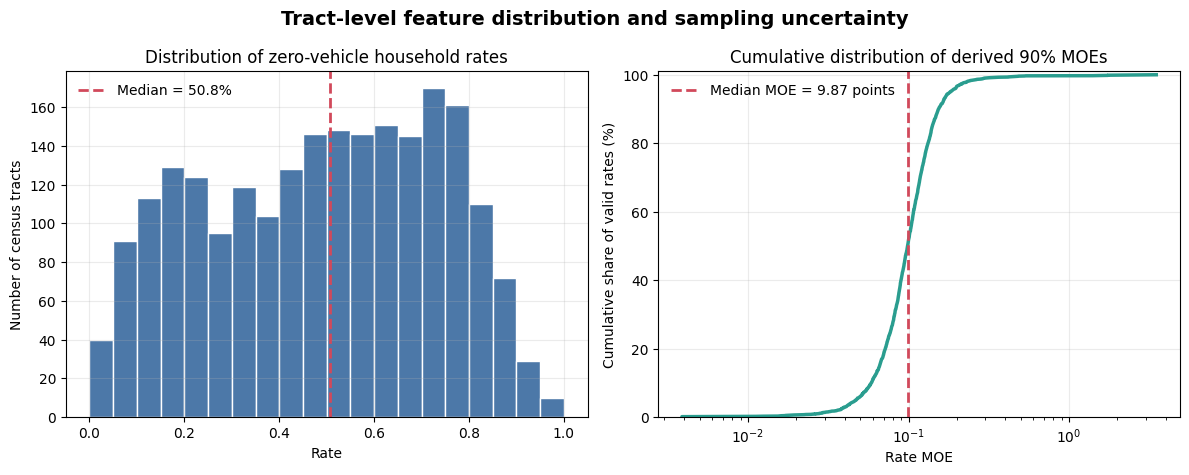

In [326]:
# Visualize the rate distribution and the cumulative spread of MOEs
valid_rates = acs_nyc["zero_vehicle_household_rate"].dropna()
valid_rate_moes = acs_nyc["zero_vehicle_rate_moe"].dropna().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].hist(valid_rates, bins=np.linspace(0, 1, 21), color="#4C78A8", edgecolor="white")
axes[0].axvline(valid_rates.median(), color="#D1495B", linestyle="--", linewidth=2, label=f"Median = {valid_rates.median() * 100:.1f}%")
axes[0].set(title="Distribution of zero-vehicle household rates", xlabel="Rate", ylabel="Number of census tracts")
axes[0].legend(frameon=False)
plotted_rate_moes = valid_rate_moes.mask(valid_rate_moes.eq(0), valid_rate_moes[valid_rate_moes.gt(0)].min() / 2)
cumulative_share = np.arange(1, len(plotted_rate_moes) + 1) / len(plotted_rate_moes) * 100
axes[1].plot(plotted_rate_moes, cumulative_share, color="#2A9D8F", linewidth=2.5)
axes[1].axvline(valid_rate_moes.median(), color="#D1495B", linestyle="--", linewidth=2, label=f"Median MOE = {valid_rate_moes.median() * 100:.2f} points")
axes[1].set_xscale("log")
axes[1].set(title="Cumulative distribution of derived 90% MOEs", xlabel="Rate MOE", ylabel="Cumulative share of valid rates (%)")
axes[1].set_ylim(0, 101)
axes[1].legend(frameon=False)
for axis in axes:
    axis.grid(alpha=0.25)
fig.suptitle("Tract-level feature distribution and sampling uncertainty", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


**Interpretation:** The feature varies widely across NYC tracts, while the cumulative MOE curve shows that most valid rates have much smaller uncertainty than the most extreme outliers.


### 8.10 Visualise Reliability for Planned Model Use


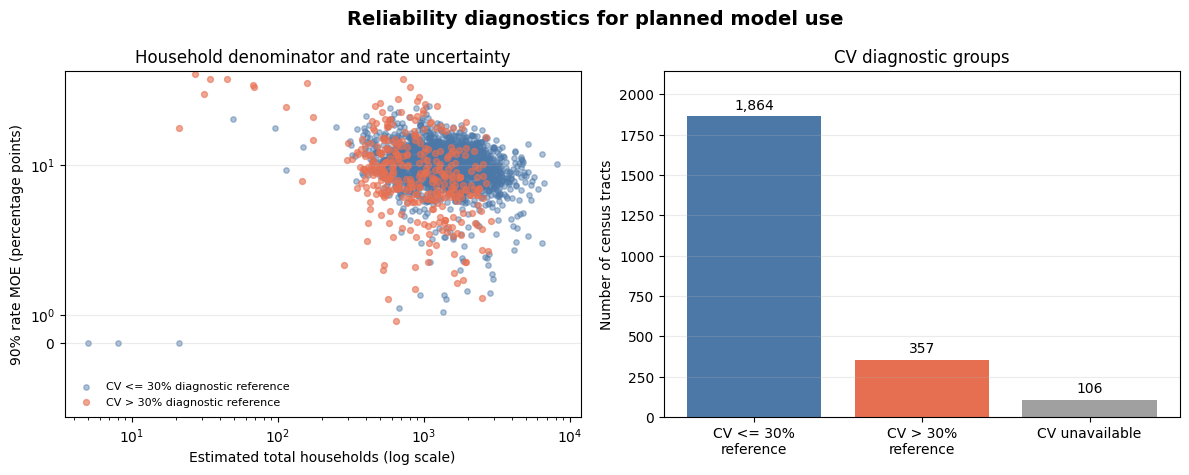

In [327]:
# Check whether uncertainty is concentrated in low-household-count tracts, as expected
cv_below_reference = acs_nyc["zero_vehicle_rate_cv"].le(0.30)
cv_above_reference = acs_nyc["zero_vehicle_rate_cv"].gt(0.30)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(
    acs_nyc.loc[cv_below_reference, "total_households_estimate"],
    acs_nyc.loc[cv_below_reference, "zero_vehicle_rate_moe"] * 100,
    s=15, alpha=0.45, color="#4C78A8", label="CV <= 30% diagnostic reference",
)
axes[0].scatter(
    acs_nyc.loc[cv_above_reference, "total_households_estimate"],
    acs_nyc.loc[cv_above_reference, "zero_vehicle_rate_moe"] * 100,
    s=18, alpha=0.60, color="#E76F51", label="CV > 30% diagnostic reference",
)
axes[0].set_xscale("log")
axes[0].set_yscale("symlog", linthresh=5)
axes[0].set(title="Household denominator and rate uncertainty", xlabel="Estimated total households (log scale)", ylabel="90% rate MOE (percentage points)")
axes[0].legend(frameon=False, fontsize=8)
reference_counts = acs_nyc["rate_cv_reference_group"].value_counts().reindex(
    ["CV <= 30% diagnostic reference", "CV > 30% diagnostic reference", "CV unavailable"], fill_value=0
)
reference_labels = ["CV <= 30%\nreference", "CV > 30%\nreference", "CV unavailable"]
bars = axes[1].bar(reference_labels, reference_counts.values, color=["#4C78A8", "#E76F51", "#A0A0A0"])
axes[1].bar_label(bars, labels=[f"{int(value):,}" for value in reference_counts.values], padding=3)
axes[1].set(title="CV diagnostic groups", ylabel="Number of census tracts")
axes[1].set_ylim(0, reference_counts.max() * 1.15)
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
fig.suptitle("Reliability diagnostics for planned model use", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


**Interpretation:** Higher relative uncertainty is concentrated in a minority of tracts, while 1,864 positive-rate tracts are at or below the 30% CV diagnostic reference, 357 are above it, and 106 have no defined CV.


### 8.11 Determine Preliminary Model-Training Suitability


In [328]:
# Written conclusion on whether this feature is fit for the planned model, based on the diagnostics above
model_training_suitability = pd.DataFrame({
    "assessment": ["Tract-level precision", "Geographic signal", "Model-training decision", "Use of uncertainty fields"],
    "finding": [
        "Not uniformly precise; a minority of tracts have relatively high uncertainty.",
        "The 24.40-point rate standard deviation and 41.88-point interquartile range exceed the 9.87-point median MOE.",
        "Provisionally suitable as a contextual feature after the planned taxi-zone conversion, with caution for high-uncertainty source tracts.",
        "Retain for quality reporting; do not use the MOE, CV, confidence limits, or diagnostic group as model predictors.",
    ],
})
display(model_training_suitability)


,assessment,finding
0,Tract-level precision,Not uniformly precise; a minority of tracts have relatively high uncertainty.
1,Geographic signal,The 24.40-point rate standard deviation and 41.88-point interquartile range exceed the 9.87-point median MOE.
2,Model-training decision,"Provisionally suitable as a contextual feature after the planned taxi-zone conversion, with caution for high-uncerta..."
3,Use of uncertainty fields,"Retain for quality reporting; do not use the MOE, CV, confidence limits, or diagnostic group as model predictors."


**Conclusion:** The feature is not uniformly precise at tract level, but it is provisionally suitable for the planned taxi-zone contextual feature because the between-tract spread is substantially larger than the typical MOE; uncertainty fields remain quality-control evidence and are not model predictors.


## 9. Load, Inspect, and Prepare Census Tract Boundaries

### 9.1 Load the New York Census Tract Shapefile

In [329]:
# TIGER/Line 2024 census tract boundaries for New York State
tract_boundaries_raw = gpd.read_file(SHAPEFILE_PATH)
tract_boundaries_raw.shape


(5411, 14)

**Interpretation:** The shapefile loaded with 5,411 New York State census-tract boundaries.

### 9.2 Inspect the Loaded Spatial Object Type

In [330]:
# Confirm it loaded as a GeoDataFrame
type(tract_boundaries_raw)


geopandas.geodataframe.GeoDataFrame

**Interpretation:** The spatial object is a GeoDataFrame, so geographic processing can continue.

### 9.3 Inspect Spatial Dimensions, Columns, and Records

In [331]:
# Inspect structure and fields before filtering
print(tract_boundaries_raw.shape)
print(tract_boundaries_raw.dtypes)
display(tract_boundaries_raw.head())


(5411, 14)
STATEFP       object
COUNTYFP      object
TRACTCE       object
GEOID         object
GEOIDFQ       object
NAME          object
NAMELSAD      object
MTFCC         object
FUNCSTAT      object
ALAND          int64
AWATER         int64
INTPTLAT      object
INTPTLON      object
geometry    geometry
dtype: object


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36,093,033102,36093033102,1400000US36093033102,331.02,Census Tract 331.02,G5020,S,183329990,3232878,+42.7780248,-074.1727005,"POLYGON ((-74.30655 42.75064, -74.30624 42.75113, -74.30593 42.75149, -74.30481 42.75219, -74.3024 42.75312, -74.301..."
1,36,093,020102,36093020102,1400000US36093020102,201.02,Census Tract 201.02,G5020,S,854905,0,+42.8295375,-073.9161408,"POLYGON ((-73.92513 42.82029, -73.9244 42.82141, -73.92367 42.8225, -73.92291 42.82362, -73.92166 42.82549, -73.9208..."
2,36,093,032504,36093032504,1400000US36093032504,325.04,Census Tract 325.04,G5020,S,65999125,1264687,+42.9010539,-074.0288936,"POLYGON ((-74.09298 42.95587, -74.08805 42.95533, -74.08735 42.95529, -74.08247 42.95498, -74.08067 42.95487, -74.07..."
3,36,081,003400,36081003400,1400000US36081003400,34,Census Tract 34,G5020,S,213987,0,+40.6847731,-073.8581871,"POLYGON ((-73.8663 40.68319, -73.86549 40.68342, -73.86533 40.68346, -73.86473 40.68364, -73.86433 40.68375, -73.863..."
4,36,081,003900,36081003900,1400000US36081003900,39,Census Tract 39,G5020,S,146970,0,+40.7627994,-073.9409316,"POLYGON ((-73.9433 40.76066, -73.94247 40.76199, -73.94139 40.76373, -73.94027 40.76553, -73.9397 40.76641, -73.9385..."


**Interpretation:** The GeoDataFrame contains 14 fields, including state, county, tract, GEOID, land, water, and polygon geometry data.

### 9.4 Inspect the Coordinate Reference System

In [332]:
# Confirm the coordinate reference system before any spatial operations
tract_boundaries_raw.crs


<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

**Interpretation:** The defined source CRS is EPSG:4269, so no CRS correction is required.

### 9.5 Inspect Geometry Types and Quality

In [333]:
# Check for missing, empty, or topologically invalid geometries
pd.Series({
    "geometry_types": tract_boundaries_raw.geometry.geom_type.value_counts().to_dict(),
    "missing_geometries": int(tract_boundaries_raw.geometry.isna().sum()),
    "empty_geometries": int(tract_boundaries_raw.geometry.is_empty.sum()),
    "invalid_geometries": int((~tract_boundaries_raw.geometry.is_valid).sum()),
})


geometry_types        {'Polygon': 5401, 'MultiPolygon': 10}
missing_geometries                                        0
empty_geometries                                          0
invalid_geometries                                        0
dtype: object

**Interpretation:** All boundaries are valid Polygon or MultiPolygon geometries with no missing, empty, or invalid shapes.

### 9.6 Display Confirmed Geometry Problems

In [334]:
# Inspect any problem geometries directly, if the check above found any
geometry_problems = tract_boundaries_raw.loc[
    tract_boundaries_raw.geometry.isna()
    | tract_boundaries_raw.geometry.is_empty
    | ~tract_boundaries_raw.geometry.is_valid
]
display(geometry_problems)


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry


**Interpretation:** No geometry problems were found, so no repair is required.

### 9.7 Inspect the Boundary GEOID Source Field

In [335]:
# GEOID here should match the same 11-digit format used on the ACS side
pd.Series({
    "dtype": str(tract_boundaries_raw["GEOID"].dtype),
    "missing": int(tract_boundaries_raw["GEOID"].isna().sum()),
    "lengths": sorted(tract_boundaries_raw["GEOID"].astype(str).str.len().unique().tolist()),
    "all_numeric_11_digits": tract_boundaries_raw["GEOID"].astype(str).str.fullmatch(r"\d{11}", na=False).all(),
    "duplicates": int(tract_boundaries_raw["GEOID"].duplicated().sum()),
})


dtype                    object
missing                       0
lengths                    [11]
all_numeric_11_digits      True
duplicates                    0
dtype: object

**Interpretation:** The boundary `GEOID` is already a unique, non-missing 11-digit string, so no formatting correction is needed.

### 9.8 Inspect Boundary State and County Coverage

In [336]:
# Tract counts per state/county in the shapefile, mirroring the ACS coverage check earlier
boundary_coverage = tract_boundaries_raw.groupby(["STATEFP", "COUNTYFP"], as_index=False).size()
display(boundary_coverage.head(10))
print(f"Distinct state-county combinations: {len(boundary_coverage)}")


,STATEFP,COUNTYFP,size
0,36,001,85
1,36,003,16
2,36,005,361
3,36,007,57
4,36,009,24
5,36,011,25
6,36,013,37
7,36,015,25
8,36,017,16
9,36,019,22


Distinct state-county combinations: 62


**Interpretation:** The boundary file provides state and county codes directly for all 62 New York counties.

### 9.9 Filter Boundaries to NYC

In [337]:
# Restrict boundaries to the same NYC counties used to filter the ACS data
nyc_boundaries = tract_boundaries_raw.loc[
    tract_boundaries_raw["STATEFP"].eq("36")
    & tract_boundaries_raw["COUNTYFP"].isin(borough_mapping)
].copy()
nyc_boundaries.shape


(2327, 14)

**Solution:** Filtering with the verified county codes retained 2,327 NYC tract boundaries.

### 9.10 Assign Borough Names to Boundaries

In [338]:
# Attach the borough name using the same mapping as the ACS side
nyc_boundaries["borough"] = nyc_boundaries["COUNTYFP"].map(borough_mapping)
nyc_boundaries[["COUNTYFP", "borough"]].drop_duplicates().sort_values("COUNTYFP")


,COUNTYFP,borough
1266,005,Bronx
29,047,Brooklyn
445,061,Manhattan
3,081,Queens
901,085,Staten Island


**Solution:** All NYC boundary records received the borough name associated with their verified county code.

### 9.11 Validate the NYC Boundaries

In [339]:
# Final checks before the spatial join: five boroughs, unique/valid GEOIDs, valid geometry, defined CRS
nyc_boundary_counts = nyc_boundaries.groupby(["COUNTYFP", "borough"]).size().rename("tracts")
display(nyc_boundary_counts)
pd.Series({
    "five_boroughs": nyc_boundaries["borough"].nunique() == 5,
    "unique_geoids": not nyc_boundaries["GEOID"].duplicated().any(),
    "valid_geoids": nyc_boundaries["GEOID"].str.fullmatch(r"\d{11}", na=False).all(),
    "valid_geometries": nyc_boundaries.geometry.is_valid.all(),
    "defined_crs": nyc_boundaries.crs is not None,
})


COUNTYFP  borough      
005       Bronx            361
047       Brooklyn         805
061       Manhattan        310
081       Queens           725
085       Staten Island    126
Name: tracts, dtype: int64

five_boroughs       True
unique_geoids       True
valid_geoids        True
valid_geometries    True
defined_crs         True
dtype: bool

**Interpretation:** The 2,327 NYC boundaries cover five boroughs with unique identifiers, valid geometries, and a defined CRS.

## 10. Join ACS Attributes to Census Tract Boundaries by GEOID

### 10.1 Inspect Both Joining Keys

In [340]:
# Confirm both join keys share dtype, are unique, and are correctly formatted before merging
join_key_review = pd.DataFrame({
    "dataset": ["ACS", "boundaries"],
    "dtype": [str(acs_nyc["tract_geoid"].dtype), str(nyc_boundaries["GEOID"].dtype)],
    "missing": [acs_nyc["tract_geoid"].isna().sum(), nyc_boundaries["GEOID"].isna().sum()],
    "unique": [acs_nyc["tract_geoid"].is_unique, nyc_boundaries["GEOID"].is_unique],
    "all_11_digit": [
        acs_nyc["tract_geoid"].str.fullmatch(r"\d{11}", na=False).all(),
        nyc_boundaries["GEOID"].str.fullmatch(r"\d{11}", na=False).all(),
    ],
    "sample": [acs_nyc["tract_geoid"].iloc[0], nyc_boundaries["GEOID"].iloc[0]],
})
join_key_review


,dataset,dtype,missing,unique,all_11_digit,sample
0,ACS,object,0,True,True,36005000100
1,boundaries,object,0,True,True,36081003400


**Interpretation:** Both joining keys are complete, unique, 11-digit strings, so no key correction is required.

### 10.2 Identify Unmatched ACS Records

In [341]:
# ACS tracts with no matching boundary geometry
unmatched_acs_geoids = sorted(set(acs_nyc["tract_geoid"]) - set(nyc_boundaries["GEOID"]))
pd.Series({"unmatched_acs_records": len(unmatched_acs_geoids), "sample": unmatched_acs_geoids[:10]})


unmatched_acs_records     0
sample                   []
dtype: object

**Interpretation:** Every NYC ACS tract identifier has a matching boundary identifier.

### 10.3 Identify Unmatched Boundary Records

In [342]:
# Boundary tracts with no matching ACS record
unmatched_boundary_geoids = sorted(set(nyc_boundaries["GEOID"]) - set(acs_nyc["tract_geoid"]))
pd.Series({"unmatched_boundary_records": len(unmatched_boundary_geoids), "sample": unmatched_boundary_geoids[:10]})


unmatched_boundary_records     0
sample                        []
dtype: object

**Interpretation:** Every NYC boundary identifier has a matching ACS tract record.

### 10.4 Join ACS Attributes to the Boundaries

In [343]:
# Assemble the final column set and merge ACS attributes onto the boundaries by GEOID
uncertainty_columns = [
    "zero_vehicle_rate_se", "zero_vehicle_rate_moe",
    "zero_vehicle_rate_ci_lower", "zero_vehicle_rate_ci_upper",
    "zero_vehicle_rate_ci_width", "zero_vehicle_rate_cv",
    "zero_vehicle_rate_moe_method", "rate_cv_reference_group",
]
acs_join_columns = [
    "tract_geoid", "NAME", "state_fips", "county_fips", "tract_code", "borough",
    *analytical_columns,
    "total_households_lower", "total_households_upper",
    "zero_vehicle_households_lower", "zero_vehicle_households_upper",
    "zero_vehicle_household_rate",
    *uncertainty_columns,
]
assert len(acs_join_columns) == len(set(acs_join_columns)), "Join columns must be unique."
acs_for_join = acs_nyc[acs_join_columns].rename(columns={"NAME": "acs_geographic_name"})
boundaries_for_join = nyc_boundaries[["GEOID", "ALAND", "AWATER", "geometry"]].rename(columns={"GEOID": "tract_geoid"})
final_gdf = boundaries_for_join.merge(acs_for_join, on="tract_geoid", how="left", validate="one_to_one")
final_gdf = gpd.GeoDataFrame(final_gdf, geometry="geometry", crs=nyc_boundaries.crs)
final_gdf.shape


(2327, 26)

**Solution:** The one-to-one GEOID-based attribute join produced 2,327 tract records with geometry and ACS analytical fields.

### 10.5 Inspect the Joined Dataset

In [344]:
# Inspect the joined GeoDataFrame's structure
print(type(final_gdf))
print(final_gdf.shape)
print(final_gdf.dtypes)
display(final_gdf.head())


<class 'geopandas.geodataframe.GeoDataFrame'>
(2327, 26)
tract_geoid                           object
ALAND                                  int64
AWATER                                 int64
geometry                            geometry
acs_geographic_name                   object
state_fips                            object
county_fips                           object
tract_code                            object
borough                               object
total_households_estimate              int64
total_households_moe                   int64
zero_vehicle_households_estimate       int64
zero_vehicle_households_moe            int64
total_households_lower                 int64
total_households_upper                 int64
zero_vehicle_households_lower          int64
zero_vehicle_households_upper          int64
zero_vehicle_household_rate          float64
zero_vehicle_rate_se                 float64
zero_vehicle_rate_moe                float64
zero_vehicle_rate_ci_lower           float6

,tract_geoid,ALAND,AWATER,geometry,acs_geographic_name,state_fips,county_fips,tract_code,borough,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe,total_households_lower,total_households_upper,zero_vehicle_households_lower,zero_vehicle_households_upper,zero_vehicle_household_rate,zero_vehicle_rate_se,zero_vehicle_rate_moe,zero_vehicle_rate_ci_lower,zero_vehicle_rate_ci_upper,zero_vehicle_rate_ci_width,zero_vehicle_rate_cv,zero_vehicle_rate_moe_method,rate_cv_reference_group
0,36081003400,213987,0,"POLYGON ((-73.8663 40.68319, -73.86549 40.68342, -73.86533 40.68346, -73.86473 40.68364, -73.86433 40.68375, -73.863...",Census Tract 34; Queens County; New York,36,081,003400,Queens,728,104,304,116,624,832,188,420,0.417582,0.089819,0.147752,0.269830,0.565335,0.295505,0.215093,proportion approximation,CV <= 30% diagnostic reference
1,36081003900,146970,0,"POLYGON ((-73.9433 40.76066, -73.94247 40.76199, -73.94139 40.76373, -73.94027 40.76553, -73.9397 40.76641, -73.9385...",Census Tract 39; Queens County; New York,36,081,003900,Queens,519,192,170,58,327,711,112,228,0.327553,0.100207,0.164840,0.162713,0.492393,0.329681,0.305926,alternative ratio approximation,CV > 30% diagnostic reference
2,36081003600,180006,0,"POLYGON ((-73.8641 40.68237, -73.8637 40.68248, -73.86282 40.68274, -73.86194 40.68299, -73.86107 40.68324, -73.8601...",Census Tract 36; Queens County; New York,36,081,003600,Queens,1070,237,369,195,833,1307,174,564,0.344860,0.100585,0.165463,0.179397,0.510322,0.330925,0.291670,proportion approximation,CV <= 30% diagnostic reference
3,36081003700,386629,14591,"POLYGON ((-73.95077 40.75531, -73.95074 40.75535, -73.95071 40.75538, -73.95066 40.75544, -73.94915 40.75733, -73.94...",Census Tract 37; Queens County; New York,36,081,003700,Queens,0,14,0,14,0,14,0,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not calculated,CV unavailable
4,36081003800,176214,0,"POLYGON ((-73.8528 40.68425, -73.85196 40.68449, -73.85111 40.68473, -73.85025 40.68498, -73.84937 40.68523, -73.848...",Census Tract 38; Queens County; New York,36,081,003800,Queens,702,90,246,90,612,792,156,336,0.350427,0.072994,0.120076,0.230352,0.470503,0.240151,0.208301,proportion approximation,CV <= 30% diagnostic reference


**Interpretation:** The joined object is a 2,327-row GeoDataFrame that preserves the tract geometry and all prepared analytical fields.

### 10.6 Validate the Join

In [345]:
# Row counts should match on both sides, with no missing joins or geometry issues introduced
pd.Series({
    "expected_row_count": len(final_gdf) == len(nyc_boundaries) == len(acs_nyc),
    "missing_joined_estimates": int(final_gdf["total_households_estimate"].isna().sum()),
    "duplicate_geoids": int(final_gdf["tract_geoid"].duplicated().sum()),
    "invalid_geometries": int((~final_gdf.geometry.is_valid).sum()),
    "crs_preserved": final_gdf.crs == nyc_boundaries.crs,
})


expected_row_count          True
missing_joined_estimates       0
duplicate_geoids               0
invalid_geometries             0
crs_preserved               True
dtype: object

**Interpretation:** The join preserved all 2,327 tracts, introduced no missing estimates or duplicate identifiers, and retained valid geometry and CRS information.

## 11. Final Quality Control

### 11.1 Inspect the Final Dataset Structure

In [346]:
# Full structural view of the final joined dataset before QC
print(final_gdf.shape)
print(final_gdf.dtypes)
display(final_gdf.head())


(2327, 26)
tract_geoid                           object
ALAND                                  int64
AWATER                                 int64
geometry                            geometry
acs_geographic_name                   object
state_fips                            object
county_fips                           object
tract_code                            object
borough                               object
total_households_estimate              int64
total_households_moe                   int64
zero_vehicle_households_estimate       int64
zero_vehicle_households_moe            int64
total_households_lower                 int64
total_households_upper                 int64
zero_vehicle_households_lower          int64
zero_vehicle_households_upper          int64
zero_vehicle_household_rate          float64
zero_vehicle_rate_se                 float64
zero_vehicle_rate_moe                float64
zero_vehicle_rate_ci_lower           float64
zero_vehicle_rate_ci_upper           float64

,tract_geoid,ALAND,AWATER,geometry,acs_geographic_name,state_fips,county_fips,tract_code,borough,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe,total_households_lower,total_households_upper,zero_vehicle_households_lower,zero_vehicle_households_upper,zero_vehicle_household_rate,zero_vehicle_rate_se,zero_vehicle_rate_moe,zero_vehicle_rate_ci_lower,zero_vehicle_rate_ci_upper,zero_vehicle_rate_ci_width,zero_vehicle_rate_cv,zero_vehicle_rate_moe_method,rate_cv_reference_group
0,36081003400,213987,0,"POLYGON ((-73.8663 40.68319, -73.86549 40.68342, -73.86533 40.68346, -73.86473 40.68364, -73.86433 40.68375, -73.863...",Census Tract 34; Queens County; New York,36,081,003400,Queens,728,104,304,116,624,832,188,420,0.417582,0.089819,0.147752,0.269830,0.565335,0.295505,0.215093,proportion approximation,CV <= 30% diagnostic reference
1,36081003900,146970,0,"POLYGON ((-73.9433 40.76066, -73.94247 40.76199, -73.94139 40.76373, -73.94027 40.76553, -73.9397 40.76641, -73.9385...",Census Tract 39; Queens County; New York,36,081,003900,Queens,519,192,170,58,327,711,112,228,0.327553,0.100207,0.164840,0.162713,0.492393,0.329681,0.305926,alternative ratio approximation,CV > 30% diagnostic reference
2,36081003600,180006,0,"POLYGON ((-73.8641 40.68237, -73.8637 40.68248, -73.86282 40.68274, -73.86194 40.68299, -73.86107 40.68324, -73.8601...",Census Tract 36; Queens County; New York,36,081,003600,Queens,1070,237,369,195,833,1307,174,564,0.344860,0.100585,0.165463,0.179397,0.510322,0.330925,0.291670,proportion approximation,CV <= 30% diagnostic reference
3,36081003700,386629,14591,"POLYGON ((-73.95077 40.75531, -73.95074 40.75535, -73.95071 40.75538, -73.95066 40.75544, -73.94915 40.75733, -73.94...",Census Tract 37; Queens County; New York,36,081,003700,Queens,0,14,0,14,0,14,0,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not calculated,CV unavailable
4,36081003800,176214,0,"POLYGON ((-73.8528 40.68425, -73.85196 40.68449, -73.85111 40.68473, -73.85025 40.68498, -73.84937 40.68523, -73.848...",Census Tract 38; Queens County; New York,36,081,003800,Queens,702,90,246,90,612,792,156,336,0.350427,0.072994,0.120076,0.230352,0.470503,0.240151,0.208301,proportion approximation,CV <= 30% diagnostic reference


**Interpretation:** The final dataset contains 2,327 tract rows and 26 documented geographic, analytical, uncertainty, and spatial fields.


### 11.2 Inspect Final Missing Values

In [347]:
# Missing-value count per column, sorted to surface the worst offenders first
final_missing = final_gdf.isna().sum().sort_values(ascending=False)
final_missing.to_frame("missing_values")


,missing_values
zero_vehicle_rate_cv,106
zero_vehicle_household_rate,96
zero_vehicle_rate_ci_lower,96
zero_vehicle_rate_se,96
zero_vehicle_rate_ci_upper,96
zero_vehicle_rate_moe,96
zero_vehicle_rate_ci_width,96
AWATER,0
tract_geoid,0
ALAND,0


**Interpretation:** The rate and its derived uncertainty fields are missing for the 96 zero-denominator tracts, while the CV is additionally undefined for 10 valid tracts whose estimated rate is zero.


### 11.3 Investigate Important Missing Values

In [348]:
# Records missing any of the columns needed for analysis or mapping
important_columns = [
    "tract_geoid", "borough", *analytical_columns,
    "zero_vehicle_household_rate", "geometry",
]
important_missing_records = final_gdf.loc[final_gdf[important_columns].isna().any(axis=1)]
display(important_missing_records[[
    "tract_geoid", "borough", "total_households_estimate",
    "zero_vehicle_households_estimate", "zero_vehicle_household_rate",
]])


,tract_geoid,borough,total_households_estimate,zero_vehicle_households_estimate,zero_vehicle_household_rate
3,36081003700,Queens,0,0,NaN
27,36081107202,Queens,0,0,NaN
52,36081099900,Queens,0,0,NaN
66,36081029900,Queens,0,0,NaN
72,36081033100,Queens,0,0,NaN
...,...,...,...,...,...
2194,36005011000,Bronx,0,0,NaN
2200,36005002400,Bronx,0,0,NaN
2261,36005050400,Bronx,0,0,NaN
2295,36081038302,Queens,0,0,NaN


**Interpretation:** The 96 displayed records are missing only the rate because their total-household estimate is zero, which follows the approved validity rule.

### 11.4 Validate Geographic Coverage

In [349]:
# Tract counts by borough in the final dataset
final_borough_counts = final_gdf.groupby(["county_fips", "borough"]).size().rename("tracts")
display(final_borough_counts)


county_fips  borough      
005          Bronx            361
047          Brooklyn         805
061          Manhattan        310
081          Queens           725
085          Staten Island    126
Name: tracts, dtype: int64

**Interpretation:** The final data cover Bronx, Brooklyn, Manhattan, Queens, and Staten Island with the expected 2,327 tract records.

### 11.5 Validate Identifier Quality

In [350]:
# Identifier integrity: unique, non-null, correctly formatted 11-digit GEOIDs
pd.Series({
    "missing_geoids": int(final_gdf["tract_geoid"].isna().sum()),
    "duplicate_geoids": int(final_gdf["tract_geoid"].duplicated().sum()),
    "all_geoids_11_digits": final_gdf["tract_geoid"].str.fullmatch(r"\d{11}", na=False).all(),
})


missing_geoids             0
duplicate_geoids           0
all_geoids_11_digits    True
dtype: object

**Interpretation:** Every final tract identifier is present, unique, and formatted as 11 digits.

### 11.6 Validate Analytical Quality

In [351]:
# Analytical integrity: numeric types, non-negative values, valid rate range and MOE consistency
pd.Series({
    "analytical_columns_numeric": all(pd.api.types.is_numeric_dtype(final_gdf[c]) for c in analytical_columns),
    "estimates_nonnegative": bool((final_gdf[["total_households_estimate", "zero_vehicle_households_estimate"]] >= 0).all().all()),
    "moes_nonnegative": bool((final_gdf[moe_columns] >= 0).all().all()),
    "valid_rate_range": final_gdf["zero_vehicle_household_rate"].dropna().between(0, 1).all(),
    "missing_rates_only_for_zero_denominator": final_gdf.loc[final_gdf["zero_vehicle_household_rate"].isna(), "total_households_estimate"].eq(0).all(),
    "derived_rate_moes_nonnegative": final_gdf["zero_vehicle_rate_moe"].dropna().ge(0).all(),
    "rate_confidence_limits_valid": (
        final_gdf["zero_vehicle_rate_ci_lower"].dropna().between(0, 1).all()
        and final_gdf["zero_vehicle_rate_ci_upper"].dropna().between(0, 1).all()
    ),
})


analytical_columns_numeric                 True
estimates_nonnegative                      True
moes_nonnegative                           True
valid_rate_range                           True
missing_rates_only_for_zero_denominator    True
derived_rate_moes_nonnegative              True
rate_confidence_limits_valid               True
dtype: bool

**Interpretation:** All analytical checks pass, and missing rates occur only where a zero denominator makes division invalid.

### 11.7 Validate Spatial Quality

In [352]:
# Spatial integrity: defined CRS, no missing/empty/invalid geometries
pd.Series({
    "defined_crs": final_gdf.crs is not None,
    "missing_geometries": int(final_gdf.geometry.isna().sum()),
    "empty_geometries": int(final_gdf.geometry.is_empty.sum()),
    "invalid_geometries": int((~final_gdf.geometry.is_valid).sum()),
})


defined_crs           True
missing_geometries       0
empty_geometries         0
invalid_geometries       0
dtype: object

**Interpretation:** The final spatial data preserve a defined CRS and contain no missing, empty, or invalid geometries.

### 11.8 Create the Final Quality-Control Summary

In [353]:
# Consolidated pass/fail summary across all the checks above
qc_summary = pd.DataFrame({
    "check": [
        "Five NYC boroughs", "Expected tract count", "Unique 11-digit GEOIDs",
        "No unmatched join keys", "Non-negative estimates", "Non-negative MOEs",
        "Valid rate policy", "Valid derived rate MOEs", "Valid rate confidence limits",
        "Valid geometries", "Defined CRS",
    ],
    "passed": [
        final_gdf["borough"].nunique() == 5,
        len(final_gdf) == 2327,
        final_gdf["tract_geoid"].is_unique and final_gdf["tract_geoid"].str.fullmatch(r"\d{11}", na=False).all(),
        len(unmatched_acs_geoids) == 0 and len(unmatched_boundary_geoids) == 0,
        (final_gdf[["total_households_estimate", "zero_vehicle_households_estimate"]] >= 0).all().all(),
        (final_gdf[moe_columns] >= 0).all().all(),
        final_gdf["zero_vehicle_household_rate"].dropna().between(0, 1).all()
        and final_gdf.loc[final_gdf["zero_vehicle_household_rate"].isna(), "total_households_estimate"].eq(0).all(),
        final_gdf["zero_vehicle_rate_moe"].dropna().ge(0).all(),
        final_gdf["zero_vehicle_rate_ci_lower"].dropna().between(0, 1).all()
        and final_gdf["zero_vehicle_rate_ci_upper"].dropna().between(0, 1).all(),
        final_gdf.geometry.notna().all() and (~final_gdf.geometry.is_empty).all() and final_gdf.geometry.is_valid.all(),
        final_gdf.crs is not None,
    ],
})
display(qc_summary)


,check,passed
0,Five NYC boroughs,True
1,Expected tract count,True
2,Unique 11-digit GEOIDs,True
3,No unmatched join keys,True
4,Non-negative estimates,True
5,Non-negative MOEs,True
6,Valid rate policy,True
7,Valid derived rate MOEs,True
8,Valid rate confidence limits,True
9,Valid geometries,True


**Interpretation:** All 11 final geographic, analytical, uncertainty, join, and spatial quality checks pass.

### 11.9 Run Essential Assertions

In [354]:
# Hard stop if any check failed — nothing gets saved on a failed QC pass
assert qc_summary["passed"].all(), "At least one final quality-control check failed."
assert len(final_gdf) == len(acs_nyc) == len(nyc_boundaries)
assert final_gdf["tract_geoid"].is_unique
"All essential assertions passed."


'All essential assertions passed.'

**Interpretation:** The assertions completed successfully, so the processed dataset satisfies every essential requirement.

## 12. Save the Processed Outputs

### 12.1 Create the Output Directory

In [355]:
# Create the output folder if it doesn't already exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


WindowsPath('C:/Asia Pacific University/All Module Notes/Semister-5/Investigations/FYP Semester 1/Progress/fyp/processed_outputs/census_tract')

### 12.2 Prepare the Non-Spatial Dataset

In [356]:
# Non-spatial version of the final table, for the CSV export
final_table = pd.DataFrame(final_gdf.drop(columns="geometry"))
final_table.shape


(2327, 25)

**Interpretation:** The non-spatial copy contains the same 2,327 records and all 25 non-geometry fields.


### 12.3 Save the Cleaned CSV

In [357]:
# Write the CSV
final_table.to_csv(CSV_OUTPUT_PATH, index=False)
CSV_OUTPUT_PATH


WindowsPath('C:/Asia Pacific University/All Module Notes/Semister-5/Investigations/FYP Semester 1/Progress/fyp/processed_outputs/census_tract/nyc_zero_vehicle_households_by_tract.csv')

**Solution:** The cleaned tract-level analytical data were saved as a CSV file.

### 12.4 Save the Joined GeoPackage

In [358]:
# GeoPackage can't handle duplicate column names — drop any before writing
if final_gdf.columns.has_duplicates:
    duplicate_columns = final_gdf.columns[final_gdf.columns.duplicated(keep="first")].tolist()
    print(f"Removing duplicate columns before export: {duplicate_columns}")
    final_gdf = final_gdf.loc[:, ~final_gdf.columns.duplicated(keep="first")]

# Overwrite any existing file rather than appending a second layer
if GPKG_OUTPUT_PATH.exists():
    GPKG_OUTPUT_PATH.unlink()
final_gdf.to_file(GPKG_OUTPUT_PATH, layer="nyc_tract_zero_vehicle", driver="GPKG")
GPKG_OUTPUT_PATH


WindowsPath('C:/Asia Pacific University/All Module Notes/Semister-5/Investigations/FYP Semester 1/Progress/fyp/processed_outputs/census_tract/nyc_zero_vehicle_households_by_tract.gpkg')

**Solution:** The joined tract-level spatial data were saved as a GeoPackage.

### 12.5 Confirm That Both Output Files Exist

In [359]:
# Confirm both output files were actually written to disk
pd.DataFrame({
    "file": [CSV_OUTPUT_PATH.name, GPKG_OUTPUT_PATH.name],
    "exists": [CSV_OUTPUT_PATH.exists(), GPKG_OUTPUT_PATH.exists()],
    "size_bytes": [CSV_OUTPUT_PATH.stat().st_size, GPKG_OUTPUT_PATH.stat().st_size],
})


,file,exists,size_bytes
0,nyc_zero_vehicle_households_by_tract.csv,True,714020
1,nyc_zero_vehicle_households_by_tract.gpkg,True,2445312


**Interpretation:** Both processed output files exist and contain non-zero bytes.

## 13. Reopen and Verify the Saved Outputs

### 13.1 Reopen the Cleaned CSV

In [360]:
# Reopen the CSV, restoring string dtype on identifier columns (CSV loses leading zeros otherwise)
reopened_csv = pd.read_csv(
    CSV_OUTPUT_PATH,
    dtype={"tract_geoid": str, "state_fips": str, "county_fips": str, "tract_code": str},
)
reopened_csv.shape


(2327, 25)

**Interpretation:** The saved CSV reopened with the expected 2,327 rows and 25 columns.


### 13.2 Validate the Reopened CSV

In [361]:
# Confirm the reopened CSV matches the in-memory table exactly
csv_validation = pd.Series({
    "same_shape": reopened_csv.shape == final_table.shape,
    "same_columns": reopened_csv.columns.tolist() == final_table.columns.tolist(),
    "same_geoids": reopened_csv["tract_geoid"].equals(final_table["tract_geoid"].reset_index(drop=True)),
    "same_estimates": np.allclose(reopened_csv["total_households_estimate"], final_table["total_households_estimate"], equal_nan=True),
    "same_rates": np.allclose(reopened_csv["zero_vehicle_household_rate"], final_table["zero_vehicle_household_rate"], equal_nan=True),
    "same_rate_moes": np.allclose(reopened_csv["zero_vehicle_rate_moe"], final_table["zero_vehicle_rate_moe"], equal_nan=True),
})
csv_validation


same_shape        True
same_columns      True
same_geoids       True
same_estimates    True
same_rates        True
same_rate_moes    True
dtype: bool

**Interpretation:** The reopened CSV matches the in-memory table in structure, identifiers, estimates, calculated rates, and derived rate MOEs.

### 13.3 Reopen the GeoPackage

In [362]:
# Reopen the GeoPackage and restore the original column order
reopened_gpkg = gpd.read_file(GPKG_OUTPUT_PATH, layer="nyc_tract_zero_vehicle")
reopened_gpkg = reopened_gpkg[final_gdf.columns]
reopened_gpkg.shape


(2327, 26)

**Interpretation:** The saved GeoPackage reopened with the expected 2,327 rows and 26 columns.


### 13.4 Validate the Reopened GeoPackage

In [363]:
# Confirm the reopened GeoPackage matches the in-memory data, including CRS and geometry validity
gpkg_validation = pd.Series({
    "same_shape": reopened_gpkg.shape == final_gdf.shape,
    "same_columns": reopened_gpkg.columns.tolist() == final_gdf.columns.tolist(),
    "same_geoids": reopened_gpkg["tract_geoid"].equals(final_gdf["tract_geoid"].reset_index(drop=True)),
    "same_crs": reopened_gpkg.crs == final_gdf.crs,
    "same_estimates": np.allclose(reopened_gpkg["total_households_estimate"], final_gdf["total_households_estimate"], equal_nan=True),
    "same_rate_moes": np.allclose(reopened_gpkg["zero_vehicle_rate_moe"], final_gdf["zero_vehicle_rate_moe"], equal_nan=True),
    "valid_geometries": reopened_gpkg.geometry.is_valid.all(),
})
gpkg_validation


same_shape          True
same_columns        True
same_geoids         True
same_crs            True
same_estimates      True
same_rate_moes      True
valid_geometries    True
dtype: bool

**Interpretation:** The reopened GeoPackage matches the in-memory spatial data in structure, identifiers, CRS, estimates, derived rate MOEs, and geometry validity.

### 13.5 Display the Final Output Summary

In [364]:
# Final side-by-side summary of both output files for the write-up
output_summary = pd.DataFrame({
    "file": [CSV_OUTPUT_PATH.name, GPKG_OUTPUT_PATH.name],
    "format": ["CSV", "GeoPackage"],
    "rows": [len(reopened_csv), len(reopened_gpkg)],
    "columns": [len(reopened_csv.columns), len(reopened_gpkg.columns)],
    "identifier_check": [bool(csv_validation["same_geoids"]), bool(gpkg_validation["same_geoids"])],
    "analytical_check": [bool(csv_validation["same_rates"]), bool(gpkg_validation["same_estimates"])],
    "spatial_check": ["Not applicable", bool(gpkg_validation["valid_geometries"] and gpkg_validation["same_crs"])],
    "reopen_check": [bool(csv_validation.all()), bool(gpkg_validation.all())],
})
display(output_summary)


,file,format,rows,columns,identifier_check,analytical_check,spatial_check,reopen_check
0,nyc_zero_vehicle_households_by_tract.csv,CSV,2327,25,True,True,Not applicable,True
1,nyc_zero_vehicle_households_by_tract.gpkg,GeoPackage,2327,26,True,True,True,True


**Interpretation:** Both outputs reopened successfully and passed their identifier, analytical, and applicable spatial checks.